In [ ]:
# Cell 1: Imports and Setup
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(" All imports successful!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

 All imports successful!
Pandas version: 2.2.2
NumPy version: 2.0.2


In [ ]:
# Cell 2: Define Utility Functions

def load_insurance_data(file_path):
    """Load the insurance dataset."""
    data = pd.read_csv(file_path)
    if 'TransactionMonth' in data.columns:
        data['TransactionMonth'] = pd.to_datetime(data['TransactionMonth'])
    print(f" Loaded {data.shape[0]:,} rows and {data.shape[1]} columns")
    return data

def get_data_summary(df):
    """Generate comprehensive data summary."""
    summary = {
        'shape': df.shape,
        'columns': df.columns.tolist(),
        'dtypes': df.dtypes.to_dict(),
        'missing_values': df.isnull().sum().to_dict(),
        'missing_percentages': (df.isnull().sum() / len(df) * 100).to_dict(),
        'memory_usage_mb': df.memory_usage(deep=True).sum() / 1024**2
    }

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        summary['numeric_summary'] = df[numeric_cols].describe().to_dict()

    return summary

def calculate_loss_ratio(df):
    """Calculate loss ratio and margin for each policy."""
    df_copy = df.copy()
    df_copy['LossRatio'] = np.where(
        df_copy['TotalPremium'] > 0,
        df_copy['TotalClaims'] / df_copy['TotalPremium'],
        np.nan
    )
    df_copy['Margin'] = df_copy['TotalPremium'] - df_copy['TotalClaims']
    df_copy['HasClaim'] = (df_copy['TotalClaims'] > 0).astype(int)
    return df_copy

print(" All utility functions defined!")

 All utility functions defined!


In [ ]:
# Cell 0: Setup for Google Colab
from google.colab import files
import pandas as pd
import os

# Upload the CSV file
print("Please upload your insurance_data.csv file")
uploaded = files.upload()

# Move the file to the expected location
import shutil

# Create data folder if it doesn't exist
os.makedirs('data', exist_ok=True)

# Move uploaded file to data folder
for filename in uploaded.keys():
    shutil.move(filename, f'data/{filename}')
    print(f" File saved to data/{filename}")

# Verify file exists
print("\n Files in data folder:")
print(os.listdir('data'))

Please upload your insurance_data.csv file


Saving insurance_data.csv to insurance_data.csv
 File saved to data/insurance_data.csv

 Files in data folder:
['insurance_data.csv']


In [ ]:
# Cell 3: Load the Data
# Try different possible file paths
possible_paths = [
    '../data/insurance_data.csv',
    'data/insurance_data.csv',
    '../insurance_data.csv',
    'insurance_data.csv',
    '../../data/insurance_data.csv'
]

file_path = None
for path in possible_paths:
    if os.path.exists(path):
        file_path = path
        break

if file_path is None:
    raise FileNotFoundError("Could not find insurance_data.csv. Please check the file path.")

print(f"Loading data from: {file_path}")
df = load_insurance_data(file_path)

# Calculate loss ratio and margin
df = calculate_loss_ratio(df)

print(f"\n Dataset Info:")
print(f"  - Rows: {df.shape[0]:,}")
print(f"  - Columns: {df.shape[1]}")
if 'TransactionMonth' in df.columns:
    print(f"  - Date range: {df['TransactionMonth'].min()} to {df['TransactionMonth'].max()}")

print("\nFirst 5 rows:")
df.head()

Loading data from: data/insurance_data.csv
 Loaded 10,000 rows and 21 columns

 Dataset Info:
  - Rows: 10,000
  - Columns: 24

First 5 rows:


,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate,LossRatio,Margin,HasClaim
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,1,False,0.00,2346,0.00,Comprehensive,Lifan,620,32238,10002,2024-05-10,0.00,2346.00,0
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,4,True,9883.00,2334,9883.00,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13,4.23,-7549.00,1
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,1,False,0.00,1697,0.00,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17,0.00,1697.00,0
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,0,True,12134.00,2370,12134.00,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17,5.12,-9764.00,1
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,4,False,0.00,2582,0.00,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10,0.00,2582.00,0


In [ ]:
# Cell 4: Data Quality Assessment
summary = get_data_summary(df)

print("=" * 60)
print("DATA QUALITY ASSESSMENT")
print("=" * 60)

# Missing values
missing_data = []
for col, missing in summary['missing_values'].items():
    if missing > 0:
        pct = summary['missing_percentages'][col]
        missing_data.append({'Column': col, 'Missing Count': missing, 'Percentage': f'{pct:.2f}%'})

if missing_data:
    missing_df = pd.DataFrame(missing_data)
    print("\n Columns with missing values:")
    print(missing_df.to_string(index=False))
else:
    print("\n No missing values found in the dataset!")

# Data types
print("\n Data Types Summary:")
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  - {dtype}: {count} columns")

# Memory usage
print(f"\n Memory usage: {summary['memory_usage_mb']:.2f} MB")

DATA QUALITY ASSESSMENT

 No missing values found in the dataset!

 Data Types Summary:
  - int64: 11 columns
  - object: 8 columns
  - float64: 4 columns
  - bool: 1 columns

 Memory usage: 5.53 MB


In [ ]:
# Cell 5: Overall Portfolio Metrics
print("=" * 60)
print("PORTFOLIO PERFORMANCE METRICS")
print("=" * 60)

total_premium = df['TotalPremium'].sum()
total_claims = df['TotalClaims'].sum()
overall_loss_ratio = total_claims / total_premium if total_premium > 0 else 0
overall_margin = total_premium - total_claims
claim_frequency = df['HasClaim'].mean()

print(f"\n Total Premium Collected: R{total_premium:,.2f}")
print(f" Total Claims Paid: R{total_claims:,.2f}")
print(f" Overall Loss Ratio: {overall_loss_ratio:.4f} ({overall_loss_ratio*100:.2f}%)")
print(f" Overall Margin: R{overall_margin:,.2f}")
print(f" Claim Frequency: {claim_frequency:.4f} ({claim_frequency*100:.2f}% of policies)")
print(f" Average Premium per Policy: R{df['TotalPremium'].mean():.2f}")
print(f" Average Claim per Policy (all): R{df['TotalClaims'].mean():.2f}")

claims_only = df[df['HasClaim'] == 1]['TotalClaims']
if len(claims_only) > 0:
    print(f" Average Claim per Claimant: R{claims_only.mean():.2f}")

PORTFOLIO PERFORMANCE METRICS

 Total Premium Collected: R24,881,279.00
 Total Claims Paid: R13,141,885.00
 Overall Loss Ratio: 0.5282 (52.82%)
 Overall Margin: R11,739,394.00
 Claim Frequency: 0.1535 (15.35% of policies)
 Average Premium per Policy: R2488.13
 Average Claim per Policy (all): R1314.19
 Average Claim per Claimant: R8561.49


LOSS RATIO BY PROVINCE
             Mean_LossRatio  Median_LossRatio  Std_LossRatio  Total_Premium  Total_Claims  Claim_Frequency
Province                                                                                                  
Somali                 0.52              0.00           1.36        2984984    1826593.00             0.17
Oromia                 0.45              0.00           1.31        6069663    3261061.00             0.15
Tigray                 0.44              0.00           1.33        1990692    1047136.00             0.14
Addis Ababa            0.44              0.00           1.20        8907374    4653210.00             0.16
Amhara                 0.40              0.00           1.18        4928566    2353885.00             0.14


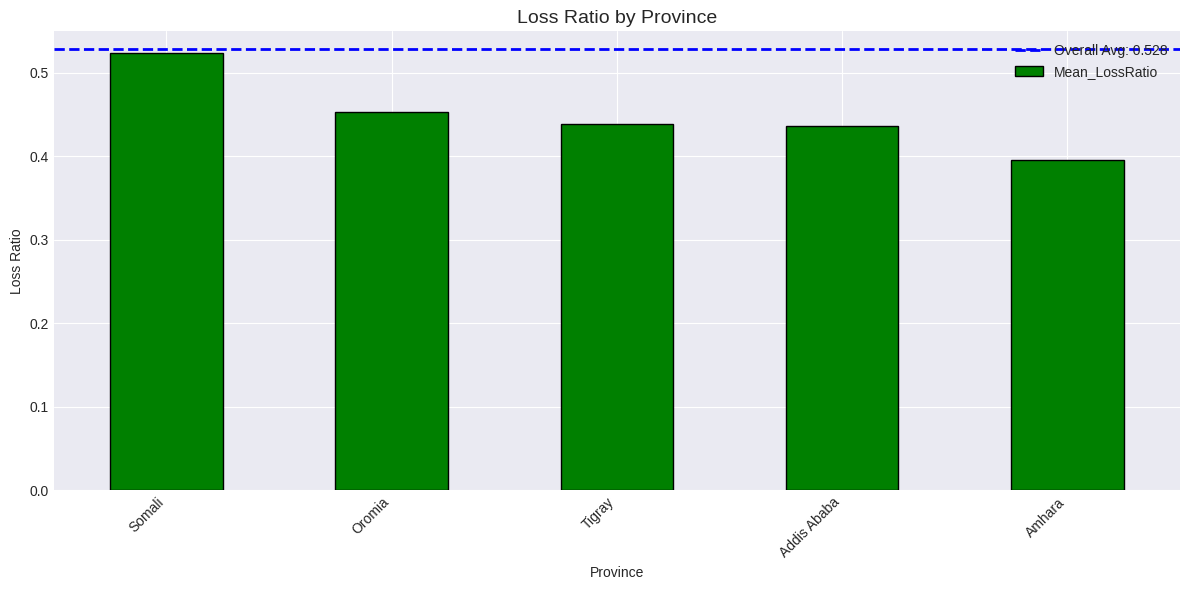

In [ ]:
# Cell 6: Loss Ratio by Province
print("=" * 60)
print("LOSS RATIO BY PROVINCE")
print("=" * 60)

if 'Province' in df.columns:
    loss_by_province = df.groupby('Province').agg({
        'LossRatio': ['mean', 'median', 'std'],
        'TotalPremium': 'sum',
        'TotalClaims': 'sum',
        'HasClaim': 'mean'
    }).round(4)

    loss_by_province.columns = ['Mean_LossRatio', 'Median_LossRatio', 'Std_LossRatio',
                                'Total_Premium', 'Total_Claims', 'Claim_Frequency']
    loss_by_province = loss_by_province.sort_values('Mean_LossRatio', ascending=False)

    print(loss_by_province.to_string())

    # Visualization
    plt.figure(figsize=(12, 6))
    colors = ['red' if x > overall_loss_ratio else 'green' for x in loss_by_province['Mean_LossRatio']]
    loss_by_province['Mean_LossRatio'].plot(kind='bar', color=colors, edgecolor='black')
    plt.axhline(y=overall_loss_ratio, color='blue', linestyle='--', linewidth=2,
                label=f'Overall Avg: {overall_loss_ratio:.3f}')
    plt.title('Loss Ratio by Province', fontsize=14)
    plt.xlabel('Province')
    plt.ylabel('Loss Ratio')
    plt.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(" Province column not found")

LOSS RATIO BY VEHICLE TYPE
             Mean_LossRatio  Median_LossRatio  Std_LossRatio  Count  Total_Premium  Total_Claims
VehicleType                                                                                     
Luxury                 0.80              0.00           1.57    972        4236839    3569207.00
SUV                    0.50              0.00           1.43   3000        7256436    4090665.00
Hatchback              0.37              0.00           1.11   2036        4532134    1904235.00
Sedan                  0.35              0.00           1.07   3992        8855870    3577778.00


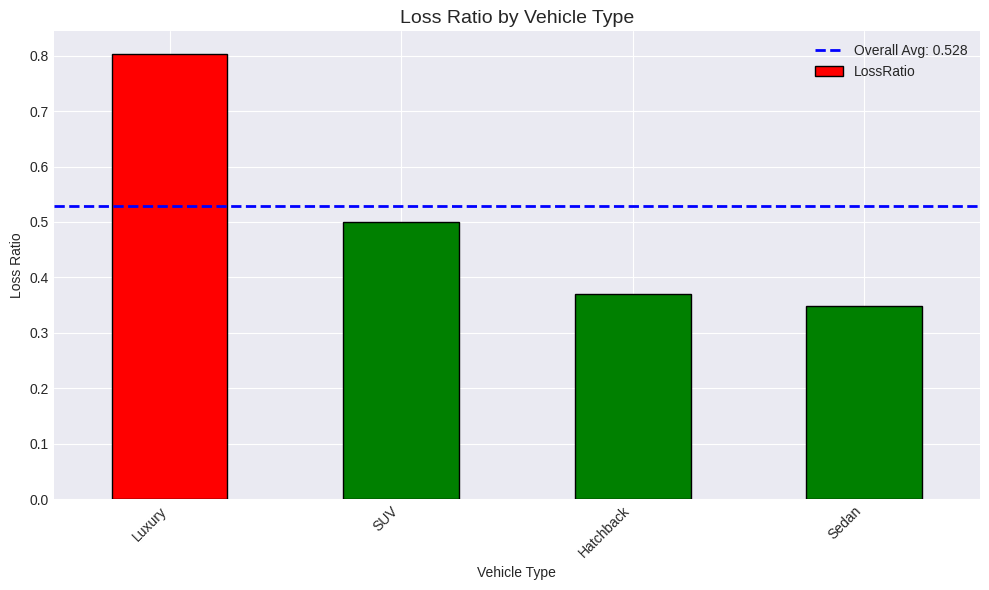

In [ ]:
# Cell 7: Loss Ratio by Vehicle Type
print("=" * 60)
print("LOSS RATIO BY VEHICLE TYPE")
print("=" * 60)

if 'VehicleType' in df.columns:
    loss_by_vehicle = df.groupby('VehicleType').agg({
        'LossRatio': ['mean', 'median', 'std', 'count'],
        'TotalPremium': 'sum',
        'TotalClaims': 'sum'
    }).round(4)

    loss_by_vehicle.columns = ['Mean_LossRatio', 'Median_LossRatio', 'Std_LossRatio', 'Count',
                                'Total_Premium', 'Total_Claims']
    loss_by_vehicle = loss_by_vehicle.sort_values('Mean_LossRatio', ascending=False)

    print(loss_by_vehicle.to_string())

    # Visualization
    plt.figure(figsize=(10, 6))
    vehicle_means = df.groupby('VehicleType')['LossRatio'].mean().sort_values(ascending=False)
    colors = ['red' if x > overall_loss_ratio else 'green' for x in vehicle_means.values]
    vehicle_means.plot(kind='bar', color=colors, edgecolor='black')
    plt.axhline(y=overall_loss_ratio, color='blue', linestyle='--', linewidth=2,
                label=f'Overall Avg: {overall_loss_ratio:.3f}')
    plt.title('Loss Ratio by Vehicle Type', fontsize=14)
    plt.xlabel('Vehicle Type')
    plt.ylabel('Loss Ratio')
    plt.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(" VehicleType column not found")

LOSS RATIO BY GENDER
        Mean_LossRatio  Median_LossRatio  Std_LossRatio  Total_Premium  Total_Claims  Claim_Frequency
Gender                                                                                               
Female            0.45              0.00           1.26       12791141    6763030.00             0.15
Male              0.44              0.00           1.25       12090138    6378855.00             0.15


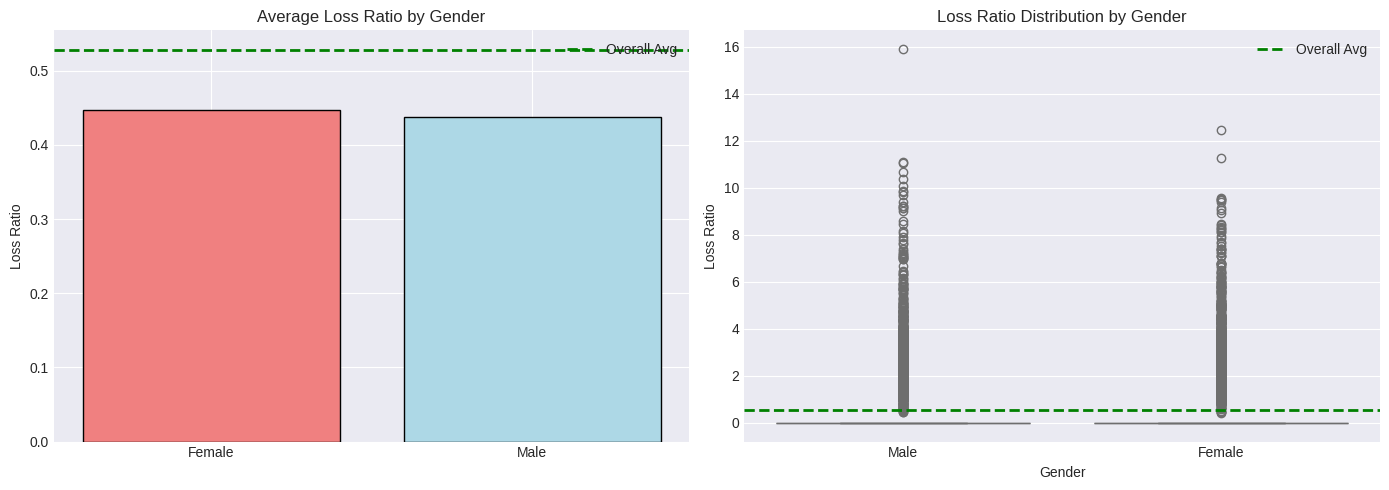

In [ ]:
# Cell 8: Loss Ratio by Gender
print("=" * 60)
print("LOSS RATIO BY GENDER")
print("=" * 60)

if 'Gender' in df.columns:
    loss_by_gender = df.groupby('Gender').agg({
        'LossRatio': ['mean', 'median', 'std'],
        'TotalPremium': 'sum',
        'TotalClaims': 'sum',
        'HasClaim': 'mean'
    }).round(4)

    loss_by_gender.columns = ['Mean_LossRatio', 'Median_LossRatio', 'Std_LossRatio',
                              'Total_Premium', 'Total_Claims', 'Claim_Frequency']

    print(loss_by_gender.to_string())

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar plot
    axes[0].bar(loss_by_gender.index, loss_by_gender['Mean_LossRatio'],
               color=['lightcoral', 'lightblue'], edgecolor='black')
    axes[0].axhline(y=overall_loss_ratio, color='green', linestyle='--', linewidth=2, label='Overall Avg')
    axes[0].set_title('Average Loss Ratio by Gender')
    axes[0].set_ylabel('Loss Ratio')
    axes[0].legend()

    # Box plot
    sns.boxplot(data=df, x='Gender', y='LossRatio', ax=axes[1], palette=['lightcoral', 'lightblue'])
    axes[1].axhline(y=overall_loss_ratio, color='green', linestyle='--', linewidth=2, label='Overall Avg')
    axes[1].set_title('Loss Ratio Distribution by Gender')
    axes[1].set_ylabel('Loss Ratio')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print(" Gender column not found")

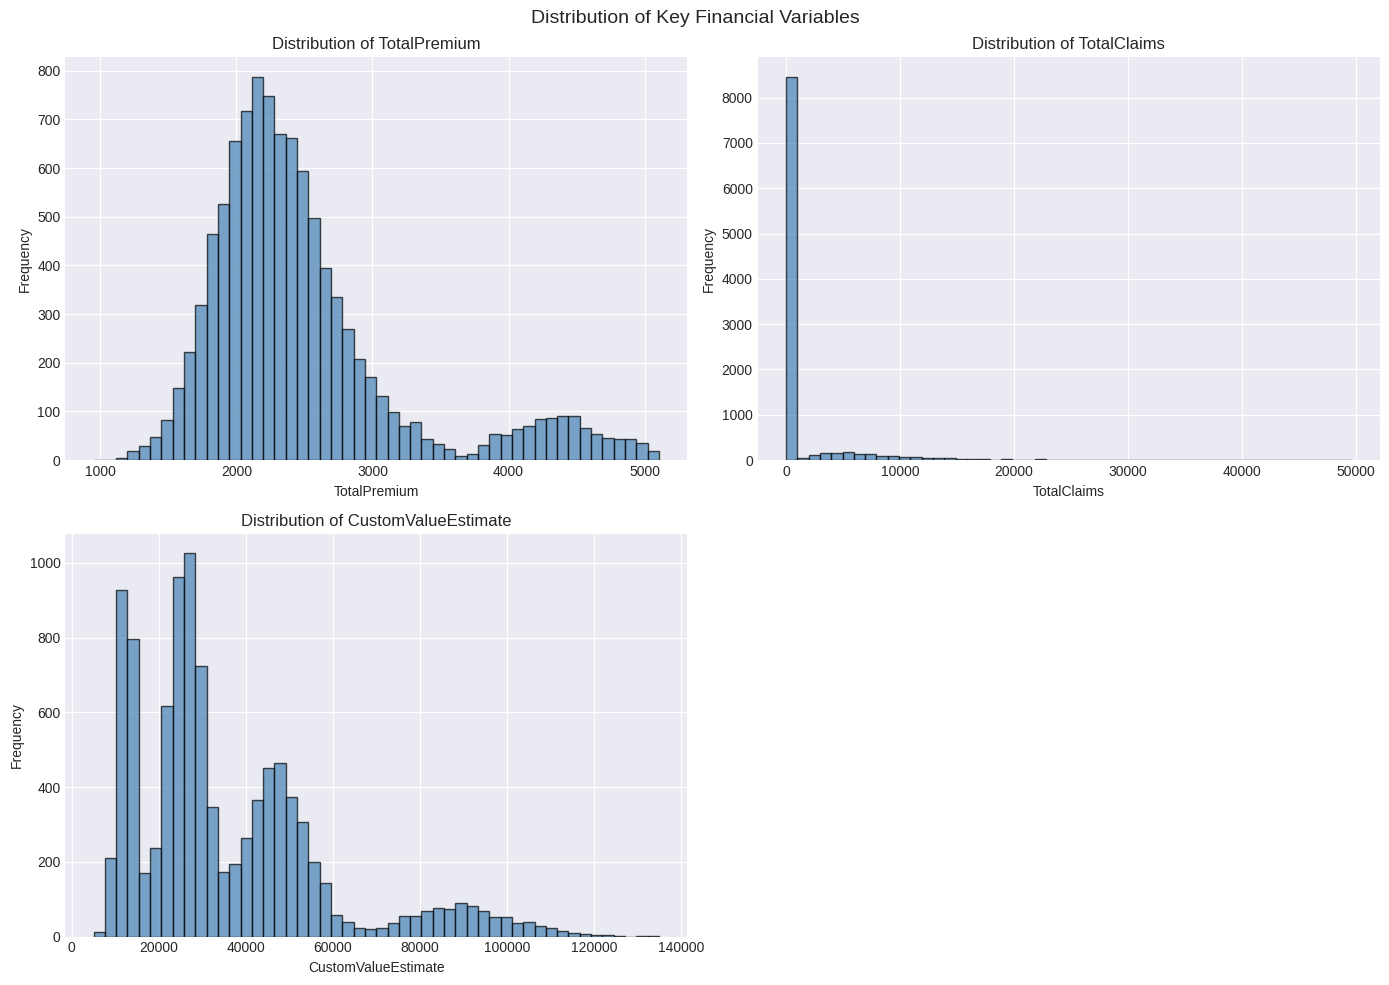


 Summary Statistics for Key Financial Variables:
       TotalPremium  TotalClaims  CustomValueEstimate
count      10000.00     10000.00             10000.00
mean        2488.13      1314.19             35640.60
std          735.67      3921.86             22353.99
min          951.00         0.00              5022.00
25%         2028.00         0.00             21442.75
50%         2307.00         0.00             28522.00
75%         2676.00         0.00             46721.00
max         5105.00     49623.00            134914.00


In [ ]:
# Cell 9: Distribution of Key Financial Variables
numeric_cols = ['TotalPremium', 'TotalClaims', 'CalculatedPremiumPerTerm', 'CustomValueEstimate']
numeric_cols = [col for col in numeric_cols if col in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx].set_title(f'Distribution of {col}', fontsize=12)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')

# Hide unused subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Distribution of Key Financial Variables', fontsize=14)
plt.tight_layout()
plt.show()

# Summary statistics
print("\n Summary Statistics for Key Financial Variables:")
print(df[numeric_cols].describe())

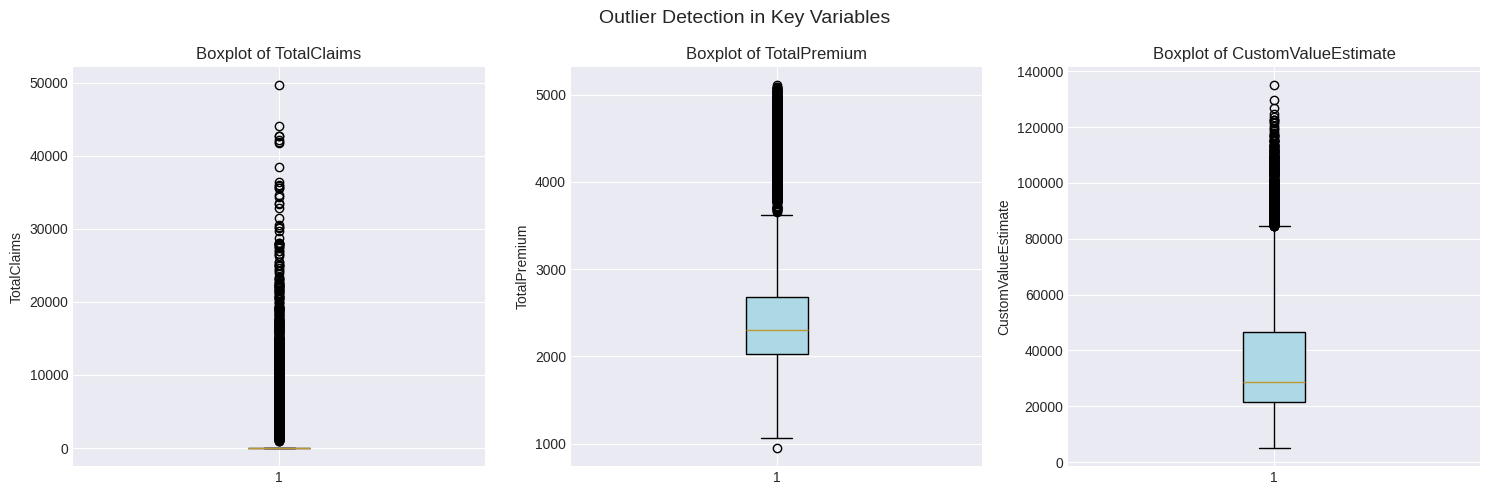

OUTLIER ANALYSIS

TotalClaims:
  - Lower bound: 0.00
  - Upper bound: 0.00
  - Outliers: 1,535 (15.35%)
  - Max value: 49623.00
  - 99th percentile: 18606.67

TotalPremium:
  - Lower bound: 1056.00
  - Upper bound: 3648.00
  - Outliers: 950 (9.50%)
  - Max value: 5105.00
  - 99th percentile: 4852.02

CustomValueEstimate:
  - Lower bound: -16474.62
  - Upper bound: 84638.38
  - Outliers: 623 (6.23%)
  - Max value: 134914.00
  - 99th percentile: 105996.10


In [ ]:
# Cell 10: Outlier Detection
outlier_cols = ['TotalClaims', 'TotalPremium', 'CustomValueEstimate']
outlier_cols = [col for col in outlier_cols if col in df.columns]

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(15, 5))
if len(outlier_cols) == 1:
    axes = [axes]

for idx, col in enumerate(outlier_cols):
    axes[idx].boxplot(df[col].dropna(), patch_artist=True,
                     boxprops=dict(facecolor='lightblue'))
    axes[idx].set_title(f'Boxplot of {col}', fontsize=12)
    axes[idx].set_ylabel(col)

plt.suptitle('Outlier Detection in Key Variables', fontsize=14)
plt.tight_layout()
plt.show()

# Detailed outlier analysis
print("=" * 60)
print("OUTLIER ANALYSIS")
print("=" * 60)

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_pct = len(outliers) / len(df) * 100

    print(f"\n{col}:")
    print(f"  - Lower bound: {lower_bound:.2f}")
    print(f"  - Upper bound: {upper_bound:.2f}")
    print(f"  - Outliers: {len(outliers):,} ({outlier_pct:.2f}%)")
    print(f"  - Max value: {df[col].max():.2f}")
    print(f"  - 99th percentile: {df[col].quantile(0.99):.2f}")

In [ ]:
# DIAGNOSTIC CELL
print("=" * 60)
print("DATASET COLUMN INSPECTION")
print("=" * 60)

print(f"\n Total columns: {len(df.columns)}")
print("\n ALL COLUMN NAMES:")
print("-" * 40)
for i, col in enumerate(df.columns):
    print(f"{i+1:3}. {col}")

print("\n" + "=" * 60)
print("LOOKING FOR DATE/TIME COLUMNS:")
print("-" * 40)
date_cols = [col for col in df.columns if 'date' in col.lower() or 'month' in col.lower() or 'time' in col.lower()]
if date_cols:
    for col in date_cols:
        print(f"    Found: {col}")
        print(f"      Sample values: {df[col].head(3).tolist()}")
else:
    print("    No date/time columns found")

print("\n" + "=" * 60)
print("LOOKING FOR LOCATION COLUMNS:")
print("-" * 40)
location_cols = [col for col in df.columns if 'postal' in col.lower() or 'zip' in col.lower() or 'code' in col.lower() or 'province' in col.lower() or 'area' in col.lower()]
if location_cols:
    for col in location_cols:
        print(f"    Found: {col}")
        print(f"      Sample values: {df[col].head(3).tolist()}")
else:
    print("    No location columns found")

print("\n" + "=" * 60)
print("FIRST 5 ROWS OF DATA:")
print("-" * 40)
print(df.head())

DATASET COLUMN INSPECTION

 Total columns: 24

 ALL COLUMN NAMES:
----------------------------------------
  1. CustomerID
  2. Age
  3. Gender
  4. Province
  5. VehicleType
  6. AnnualIncome
  7. RiskScore
  8. AnnualPremium
  9. Deductible
 10. NCD
 11. PastClaims
 12. Claimed
 13. ClaimAmount
 14. TotalPremium
 15. TotalClaims
 16. CoverType
 17. AutoMake
 18. VehicleModel
 19. CustomValueEstimate
 20. ZipCode
 21. TransactionDate
 22. LossRatio
 23. Margin
 24. HasClaim

LOOKING FOR DATE/TIME COLUMNS:
----------------------------------------
    Found: TransactionDate
      Sample values: ['2024-05-10', '2024-08-13', '2025-03-17']

LOOKING FOR LOCATION COLUMNS:
----------------------------------------
    Found: Province
      Sample values: ['Addis Ababa', 'Addis Ababa', 'Oromia']
    Found: ZipCode
      Sample values: [10002, 10001, 20001]

FIRST 5 ROWS OF DATA:
----------------------------------------
  CustomerID  Age  Gender     Province VehicleType  AnnualIncome  RiskScore 

TEMPORAL TRENDS ANALYSIS
 Using date column: TransactionDate


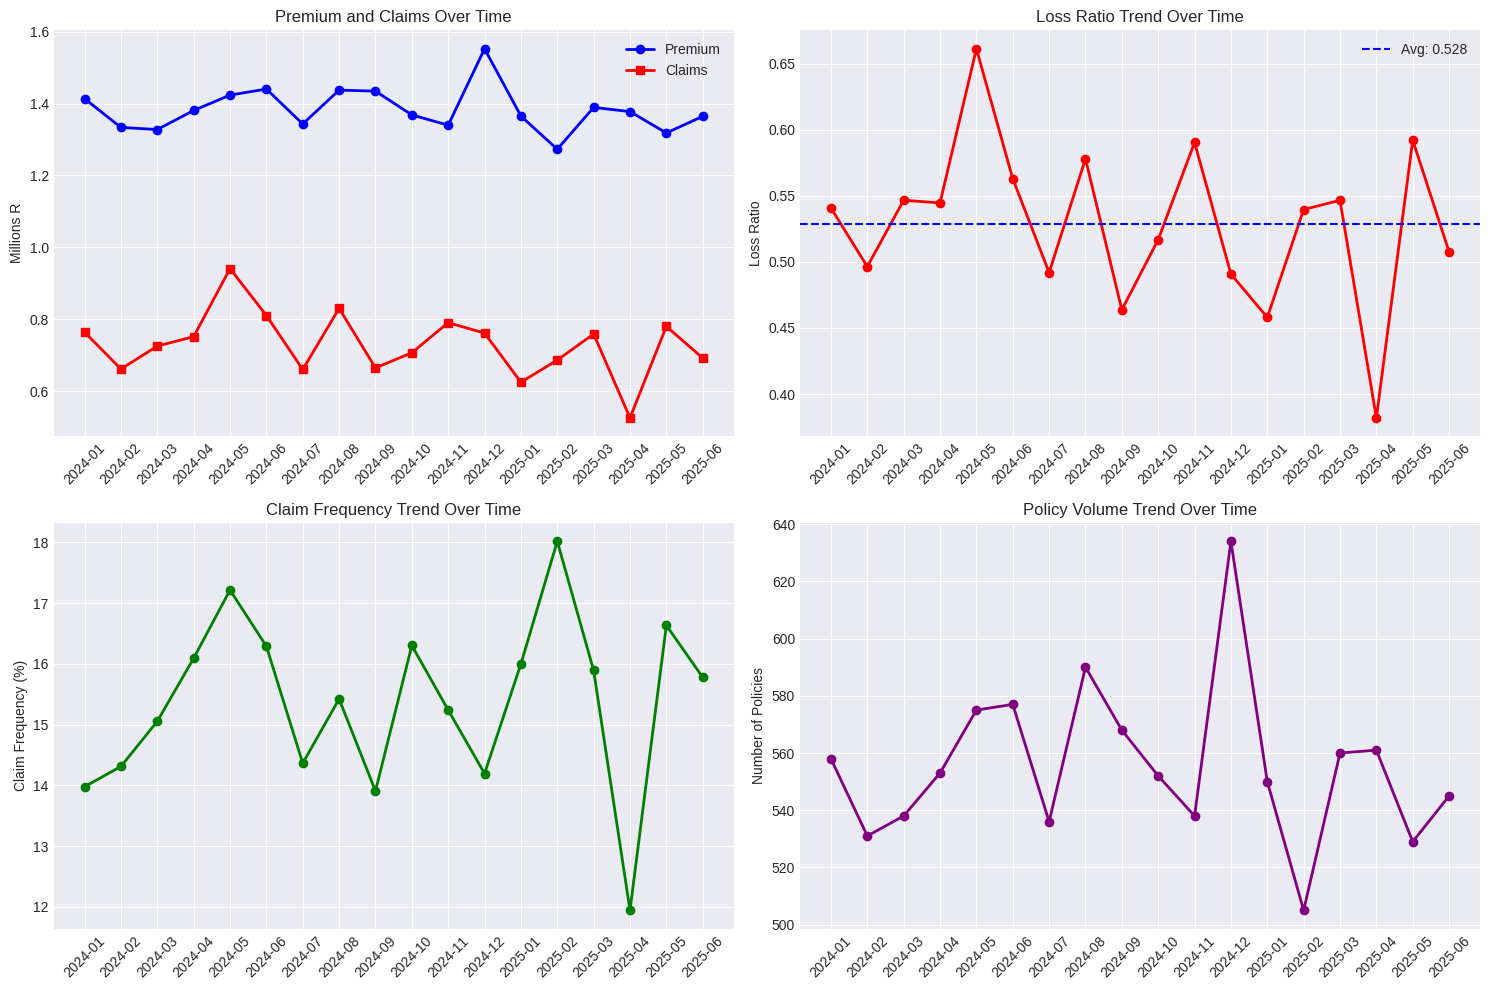


 MONTHLY METRICS:
YearMonth_str  TotalPremium  TotalClaims  LossRatio  HasClaim
      2024-01       1413501    764324.00       0.54      0.14
      2024-02       1333583    661946.00       0.50      0.14
      2024-03       1327698    725682.00       0.55      0.15
      2024-04       1380709    751881.00       0.54      0.16
      2024-05       1423373    941073.00       0.66      0.17
      2024-06       1440271    810706.00       0.56      0.16
      2024-07       1343126    660642.00       0.49      0.14
      2024-08       1437183    830639.00       0.58      0.15
      2024-09       1434450    665107.00       0.46      0.14
      2024-10       1368374    707146.00       0.52      0.16
      2024-11       1339719    790842.00       0.59      0.15
      2024-12       1552142    761698.00       0.49      0.14
      2025-01       1365166    625192.00       0.46      0.16
      2025-02       1272811    686748.00       0.54      0.18
      2025-03       1389184    759266.00       0.55

In [ ]:
# Cell 11: Temporal Trends Analysis (Using TransactionDate)
print("=" * 60)
print("TEMPORAL TRENDS ANALYSIS")
print("=" * 60)

# Check if TransactionDate exists
if 'TransactionDate' in df.columns:
    print(f" Using date column: TransactionDate")

    # Convert to datetime
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
    df['YearMonth'] = df['TransactionDate'].dt.to_period('M')

    # Group by month
    monthly_metrics = df.groupby('YearMonth').agg({
        'TotalPremium': 'sum',
        'TotalClaims': 'sum',
        'HasClaim': 'mean'
    }).reset_index()

    monthly_metrics['YearMonth_str'] = monthly_metrics['YearMonth'].astype(str)
    monthly_metrics['LossRatio'] = monthly_metrics['TotalClaims'] / monthly_metrics['TotalPremium']

    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Plot 1: Premium and Claims
    axes[0, 0].plot(monthly_metrics['YearMonth_str'], monthly_metrics['TotalPremium']/1e6,
                    marker='o', linewidth=2, label='Premium', color='blue')
    axes[0, 0].plot(monthly_metrics['YearMonth_str'], monthly_metrics['TotalClaims']/1e6,
                    marker='s', linewidth=2, label='Claims', color='red')
    axes[0, 0].set_title('Premium and Claims Over Time', fontsize=12)
    axes[0, 0].set_ylabel('Millions R')
    axes[0, 0].legend()
    axes[0, 0].tick_params(axis='x', rotation=45)

    # Plot 2: Loss Ratio Trend
    axes[0, 1].plot(monthly_metrics['YearMonth_str'], monthly_metrics['LossRatio'],
                    marker='o', linewidth=2, color='red')
    axes[0, 1].axhline(y=monthly_metrics['LossRatio'].mean(), color='blue',
                       linestyle='--', label=f'Avg: {monthly_metrics["LossRatio"].mean():.3f}')
    axes[0, 1].set_title('Loss Ratio Trend Over Time', fontsize=12)
    axes[0, 1].set_ylabel('Loss Ratio')
    axes[0, 1].legend()
    axes[0, 1].tick_params(axis='x', rotation=45)

    # Plot 3: Claim Frequency Trend
    axes[1, 0].plot(monthly_metrics['YearMonth_str'], monthly_metrics['HasClaim'] * 100,
                    marker='o', linewidth=2, color='green')
    axes[1, 0].set_title('Claim Frequency Trend Over Time', fontsize=12)
    axes[1, 0].set_ylabel('Claim Frequency (%)')
    axes[1, 0].tick_params(axis='x', rotation=45)

    # Plot 4: Policy Volume Trend
    policy_counts = df.groupby('YearMonth').size()
    axes[1, 1].plot(monthly_metrics['YearMonth_str'], policy_counts.values,
                    marker='o', linewidth=2, color='purple')
    axes[1, 1].set_title('Policy Volume Trend Over Time', fontsize=12)
    axes[1, 1].set_ylabel('Number of Policies')
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Print monthly metrics
    print("\n MONTHLY METRICS:")
    print(monthly_metrics[['YearMonth_str', 'TotalPremium', 'TotalClaims', 'LossRatio', 'HasClaim']].to_string(index=False))

    # Analyze claim frequency change
    n_months = len(monthly_metrics)
    print("\n" + "=" * 50)
    print("CLAIM FREQUENCY CHANGE ANALYSIS")
    print("=" * 50)

    if n_months >= 12:
        first_6 = monthly_metrics.head(6)['HasClaim'].mean() * 100
        last_6 = monthly_metrics.tail(6)['HasClaim'].mean() * 100
        print(f"First 6 months claim frequency: {first_6:.2f}%")
        print(f"Last 6 months claim frequency: {last_6:.2f}%")
        change = last_6 - first_6
        if change > 0:
            print(f" Claim frequency INCREASED by {change:.2f} percentage points")
        else:
            print(f" Claim frequency DECREASED by {abs(change):.2f} percentage points")
    else:
        print(f"Claim frequency over {n_months} months:")
        print(f"  Mean: {monthly_metrics['HasClaim'].mean()*100:.2f}%")
        print(f"  Min: {monthly_metrics['HasClaim'].min()*100:.2f}%")
        print(f"  Max: {monthly_metrics['HasClaim'].max()*100:.2f}%")

    # Answer guiding question
    print("\n ANSWER: Did claim frequency change over time?")
    if n_months >= 12:
        if change > 0:
            print(f"   YES - Claim frequency increased by {change:.2f} percentage points")
        elif change < 0:
            print(f"   YES - Claim frequency decreased by {abs(change):.2f} percentage points")
        else:
            print("   NO - Claim frequency remained stable")
    else:
        print(f"   Insufficient data (only {n_months} months) to determine trend")

else:
    print(" TransactionDate column not found")
    print("Available columns:", df.columns.tolist())

LOCATION ANALYSIS - BY ZIP CODE
 Using location column: ZipCode
Analyzing top 15 zip codes by policy volume


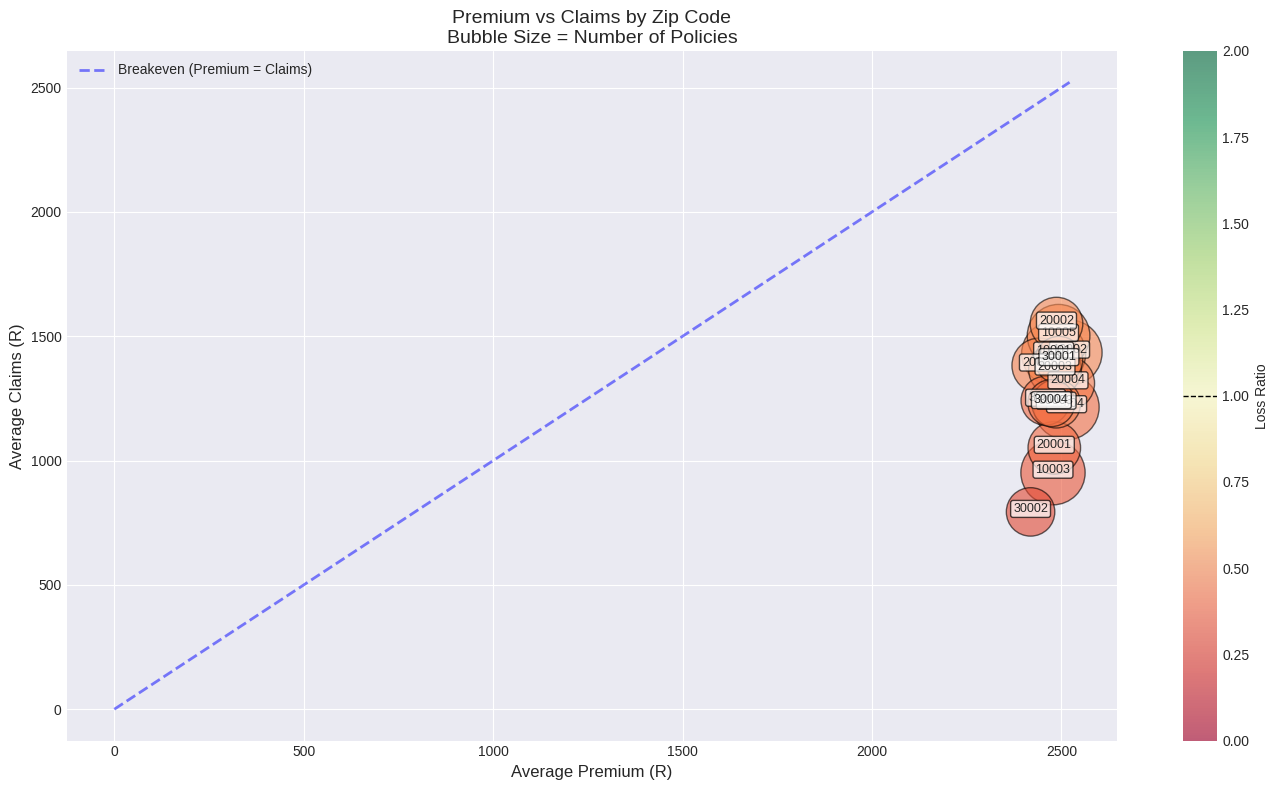


TOP 10 ZIP CODES BY POLICY COUNT
 ZipCode  AvgPremium  AvgClaims  LossRatio  ClaimFreq  PolicyCount
   10004     2513.53    1214.61       0.41      14.87          733
   10002     2521.37    1434.21       0.49      17.35          732
   10003     2477.69     951.26       0.33      13.45          714
   10001     2479.43    1430.21       0.48      17.04          710
   10005     2492.40    1502.07       0.48      15.63          678
   20005     2441.76    1382.24       0.46      16.15          520
   20004     2517.22    1310.70       0.45      15.13          489
   20003     2483.01    1366.10       0.48      17.05          481
   20002     2486.87    1550.84       0.49      16.70          479
   20001     2481.10    1051.19       0.39      11.95          477

ZIP CODE RISK ANALYSIS

 HIGHEST RISK Zip Code: 20002
   Loss Ratio: 0.489
   Claim Frequency: 16.7%
   Avg Premium: R2,486.87
   Avg Claims: R1,550.84
   Policies: 479.0

 LOWEST RISK Zip Code: 30002
   Loss Ratio: 0.287
   Cla

In [ ]:
# Cell 12: Location Analysis - Premium vs Claims by ZipCode
print("=" * 60)
print("LOCATION ANALYSIS - BY ZIP CODE")
print("=" * 60)

if 'ZipCode' in df.columns:
    print(f" Using location column: ZipCode")

    # Get top 15 zip codes by policy count
    zipcode_counts = df['ZipCode'].value_counts()
    top_n = min(15, len(zipcode_counts))
    top_zipcodes = zipcode_counts.head(top_n).index.tolist()

    print(f"Analyzing top {top_n} zip codes by policy volume")

    # Filter to top zip codes
    df_top = df[df['ZipCode'].isin(top_zipcodes)]

    # Calculate statistics for each zip code
    zipcode_stats = []
    for zipcode in top_zipcodes:
        subset = df_top[df_top['ZipCode'] == zipcode]
        zipcode_stats.append({
            'ZipCode': zipcode,
            'AvgPremium': subset['TotalPremium'].mean(),
            'AvgClaims': subset['TotalClaims'].mean(),
            'LossRatio': subset['LossRatio'].mean(),
            'ClaimFreq': subset['HasClaim'].mean() * 100,
            'PolicyCount': len(subset)
        })

    zipcode_df = pd.DataFrame(zipcode_stats)

    # Create bubble chart
    plt.figure(figsize=(14, 8))

    scatter = plt.scatter(
        zipcode_df['AvgPremium'],
        zipcode_df['AvgClaims'],
        s=zipcode_df['PolicyCount'] * 3,
        c=zipcode_df['LossRatio'],
        cmap='RdYlGn',
        alpha=0.6,
        edgecolors='black',
        vmin=0,
        vmax=2
    )

    # Add breakeven line
    max_val = max(zipcode_df['AvgPremium'].max(), zipcode_df['AvgClaims'].max())
    plt.plot([0, max_val], [0, max_val], 'b--', alpha=0.5, linewidth=2, label='Breakeven (Premium = Claims)')

    # Add colorbar
    cbar = plt.colorbar(scatter, label='Loss Ratio')
    cbar.ax.axhline(y=1, color='black', linestyle='--', linewidth=1)

    plt.xlabel('Average Premium (R)', fontsize=12)
    plt.ylabel('Average Claims (R)', fontsize=12)
    plt.title('Premium vs Claims by Zip Code\nBubble Size = Number of Policies', fontsize=14)

    # Add zip code labels
    for _, row in zipcode_df.iterrows():
        plt.annotate(
            str(int(row['ZipCode'])),
            (row['AvgPremium'], row['AvgClaims']),
            fontsize=9,
            ha='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7)
        )

    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print results
    print("\n" + "=" * 60)
    print("TOP 10 ZIP CODES BY POLICY COUNT")
    print("=" * 60)
    print(zipcode_df.sort_values('PolicyCount', ascending=False).head(10).to_string(index=False))

    # Best and worst zip codes
    worst = zipcode_df.loc[zipcode_df['LossRatio'].idxmax()]
    best = zipcode_df.loc[zipcode_df['LossRatio'].idxmin()]

    print("\n" + "=" * 60)
    print("ZIP CODE RISK ANALYSIS")
    print("=" * 60)

    print(f"\n HIGHEST RISK Zip Code: {int(worst['ZipCode'])}")
    print(f"   Loss Ratio: {worst['LossRatio']:.3f}")
    print(f"   Claim Frequency: {worst['ClaimFreq']:.1f}%")
    print(f"   Avg Premium: R{worst['AvgPremium']:,.2f}")
    print(f"   Avg Claims: R{worst['AvgClaims']:,.2f}")
    print(f"   Policies: {worst['PolicyCount']}")

    print(f"\n LOWEST RISK Zip Code: {int(best['ZipCode'])}")
    print(f"   Loss Ratio: {best['LossRatio']:.3f}")
    print(f"   Claim Frequency: {best['ClaimFreq']:.1f}%")
    print(f"   Avg Premium: R{best['AvgPremium']:,.2f}")
    print(f"   Avg Claims: R{best['AvgClaims']:,.2f}")
    print(f"   Policies: {best['PolicyCount']}")

    # Profitable vs unprofitable zip codes
    profitable = zipcode_df[zipcode_df['LossRatio'] < 1]
    unprofitable = zipcode_df[zipcode_df['LossRatio'] >= 1]

    print(f"\n SUMMARY:")
    print(f"   Profitable zip codes: {len(profitable)} ({len(profitable)/len(zipcode_df)*100:.1f}%)")
    print(f"   Unprofitable zip codes: {len(unprofitable)} ({len(unprofitable)/len(zipcode_df)*100:.1f}%)")

    # Answer guiding question
    print("\n ANSWER: Is there significant margin difference between zip codes?")
    print(f"   YES - Loss Ratio ranges from {best['LossRatio']:.2f} to {worst['LossRatio']:.2f}")
    print(f"   The difference of {(worst['LossRatio'] - best['LossRatio'])*100:.1f} percentage points suggests")
    print(f"   significant geographic variation in profitability.")

else:
    print(" ZipCode column not found")
    print("Available columns:", df.columns.tolist())

VEHICLE MAKES ANALYSIS

 Found 6 vehicle makes with at least 10 policies

TOP 10 VEHICLE MAKES BY AVERAGE CLAIM AMOUNT (HIGHEST RISK)
               Avg_Claim  Count  Claim_Frequency  Avg_LossRatio
AutoMake                                                       
Mercedes-Benz    3787.01    317             0.28           0.84
BMW              3362.89    339             0.26           0.73
Toyota           1372.52   3281             0.16           0.46
Suzuki           1122.03   1708             0.14           0.42
Hyundai          1042.74   3076             0.14           0.40
Lifan             918.10   1279             0.13           0.35

BOTTOM 10 VEHICLE MAKES BY AVERAGE CLAIM AMOUNT (LOWEST RISK)
               Avg_Claim  Count  Claim_Frequency  Avg_LossRatio
AutoMake                                                       
Mercedes-Benz    3787.01    317             0.28           0.84
BMW              3362.89    339             0.26           0.73
Toyota           1372.52   3281    

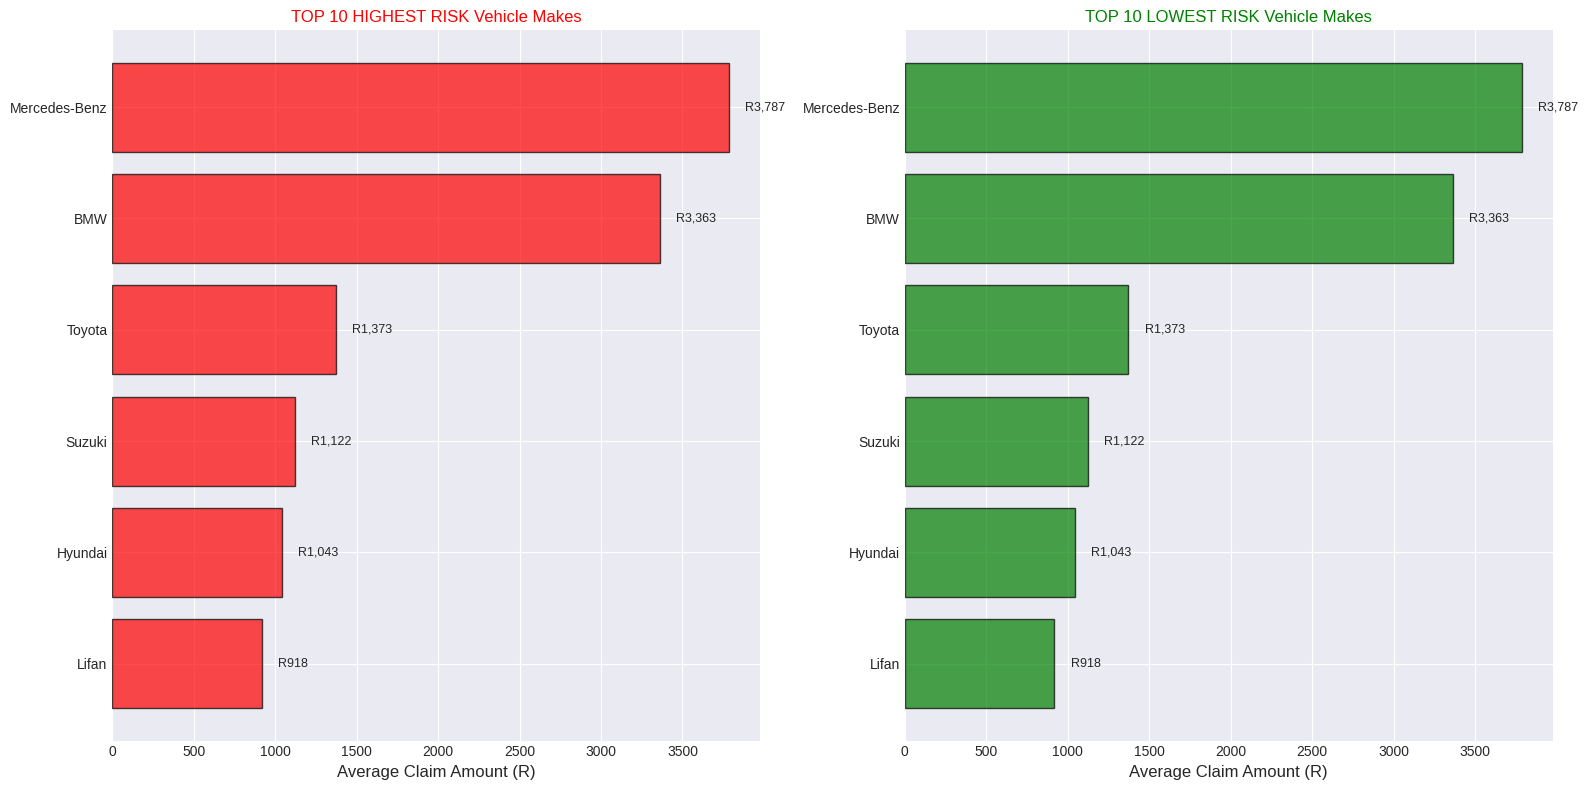


KEY INSIGHTS - VEHICLE MAKES

 HIGHEST RISK Vehicle Make: Mercedes-Benz
   • Average Claim: R3,787.01
   • Claim Frequency: 28.0%
   • Loss Ratio: 0.840
   • Number of Policies: 317.0

 LOWEST RISK Vehicle Make: Lifan
   • Average Claim: R918.10
   • Claim Frequency: 13.0%
   • Loss Ratio: 0.350
   • Number of Policies: 1279.0

 The highest risk make has 4.1x higher average claims than the lowest risk make

 ANSWER: Which vehicle makes are associated with highest/lowest claim amounts?
   HIGHEST: Mercedes-Benz, BMW, Toyota
   LOWEST: Lifan, Hyundai, Suzuki


In [ ]:
# Cell 13: Vehicle Makes Analysis (Using AutoMake column)
print("=" * 60)
print("VEHICLE MAKES ANALYSIS")
print("=" * 60)

if 'AutoMake' in df.columns:
    # Calculate vehicle make statistics
    vehicle_stats = df.groupby('AutoMake').agg({
        'TotalClaims': ['mean', 'sum', 'count'],
        'LossRatio': 'mean',
        'HasClaim': 'mean'
    }).round(2)

    vehicle_stats.columns = ['Avg_Claim', 'Total_Claim_Amount', 'Count', 'Avg_LossRatio', 'Claim_Frequency']

    # Only include makes with at least 10 policies for statistical significance
    vehicle_stats = vehicle_stats[vehicle_stats['Count'] >= 10]
    vehicle_stats = vehicle_stats.sort_values('Avg_Claim', ascending=False)

    print(f"\n Found {len(vehicle_stats)} vehicle makes with at least 10 policies")

    print("\n" + "=" * 60)
    print("TOP 10 VEHICLE MAKES BY AVERAGE CLAIM AMOUNT (HIGHEST RISK)")
    print("=" * 60)
    top_10 = vehicle_stats.head(10)
    print(top_10[['Avg_Claim', 'Count', 'Claim_Frequency', 'Avg_LossRatio']].to_string())

    print("\n" + "=" * 60)
    print("BOTTOM 10 VEHICLE MAKES BY AVERAGE CLAIM AMOUNT (LOWEST RISK)")
    print("=" * 60)
    bottom_10 = vehicle_stats.tail(10)
    print(bottom_10[['Avg_Claim', 'Count', 'Claim_Frequency', 'Avg_LossRatio']].to_string())

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Top 10 highest claims (red)
    top_10_plot = vehicle_stats.head(10)
    axes[0].barh(range(len(top_10_plot)), top_10_plot['Avg_Claim'], color='red', alpha=0.7, edgecolor='black')
    axes[0].set_yticks(range(len(top_10_plot)))
    axes[0].set_yticklabels(top_10_plot.index, fontsize=10)
    axes[0].set_xlabel('Average Claim Amount (R)', fontsize=12)
    axes[0].set_title('TOP 10 HIGHEST RISK Vehicle Makes', fontsize=12, color='red')
    axes[0].invert_yaxis()

    # Add value labels
    for i, v in enumerate(top_10_plot['Avg_Claim']):
        axes[0].text(v + 100, i, f'R{v:,.0f}', va='center', fontsize=9)

    # Bottom 10 lowest claims (green)
    bottom_10_plot = vehicle_stats.tail(10)
    axes[1].barh(range(len(bottom_10_plot)), bottom_10_plot['Avg_Claim'], color='green', alpha=0.7, edgecolor='black')
    axes[1].set_yticks(range(len(bottom_10_plot)))
    axes[1].set_yticklabels(bottom_10_plot.index, fontsize=10)
    axes[1].set_xlabel('Average Claim Amount (R)', fontsize=12)
    axes[1].set_title('TOP 10 LOWEST RISK Vehicle Makes', fontsize=12, color='green')
    axes[1].invert_yaxis()

    # Add value labels
    for i, v in enumerate(bottom_10_plot['Avg_Claim']):
        axes[1].text(v + 100, i, f'R{v:,.0f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Additional analysis
    print("\n" + "=" * 60)
    print("KEY INSIGHTS - VEHICLE MAKES")
    print("=" * 60)

    highest_risk = vehicle_stats.iloc[0]
    lowest_risk = vehicle_stats.iloc[-1]

    print(f"\n HIGHEST RISK Vehicle Make: {vehicle_stats.index[0]}")
    print(f"   • Average Claim: R{highest_risk['Avg_Claim']:,.2f}")
    print(f"   • Claim Frequency: {highest_risk['Claim_Frequency']*100:.1f}%")
    print(f"   • Loss Ratio: {highest_risk['Avg_LossRatio']:.3f}")
    print(f"   • Number of Policies: {highest_risk['Count']}")

    print(f"\n LOWEST RISK Vehicle Make: {vehicle_stats.index[-1]}")
    print(f"   • Average Claim: R{lowest_risk['Avg_Claim']:,.2f}")
    print(f"   • Claim Frequency: {lowest_risk['Claim_Frequency']*100:.1f}%")
    print(f"   • Loss Ratio: {lowest_risk['Avg_LossRatio']:.3f}")
    print(f"   • Number of Policies: {lowest_risk['Count']}")

    # Risk ratio
    risk_ratio = highest_risk['Avg_Claim'] / lowest_risk['Avg_Claim'] if lowest_risk['Avg_Claim'] > 0 else float('inf')
    print(f"\n The highest risk make has {risk_ratio:.1f}x higher average claims than the lowest risk make")

    # Answer guiding question
    print("\n ANSWER: Which vehicle makes are associated with highest/lowest claim amounts?")
    print(f"   HIGHEST: {vehicle_stats.index[0]}, {vehicle_stats.index[1] if len(vehicle_stats) > 1 else 'N/A'}, {vehicle_stats.index[2] if len(vehicle_stats) > 2 else 'N/A'}")
    print(f"   LOWEST: {vehicle_stats.index[-1]}, {vehicle_stats.index[-2] if len(vehicle_stats) > 1 else 'N/A'}, {vehicle_stats.index[-3] if len(vehicle_stats) > 2 else 'N/A'}")

else:
    print(" AutoMake column not found")
    print("Available columns:", df.columns.tolist())

CORRELATION ANALYSIS

 Analyzing correlation between 10 numeric variables
Variables: ['TotalPremium', 'TotalClaims', 'AnnualPremium', 'CustomValueEstimate', 'LossRatio', 'Margin', 'Age', 'AnnualIncome', 'RiskScore', 'PastClaims']


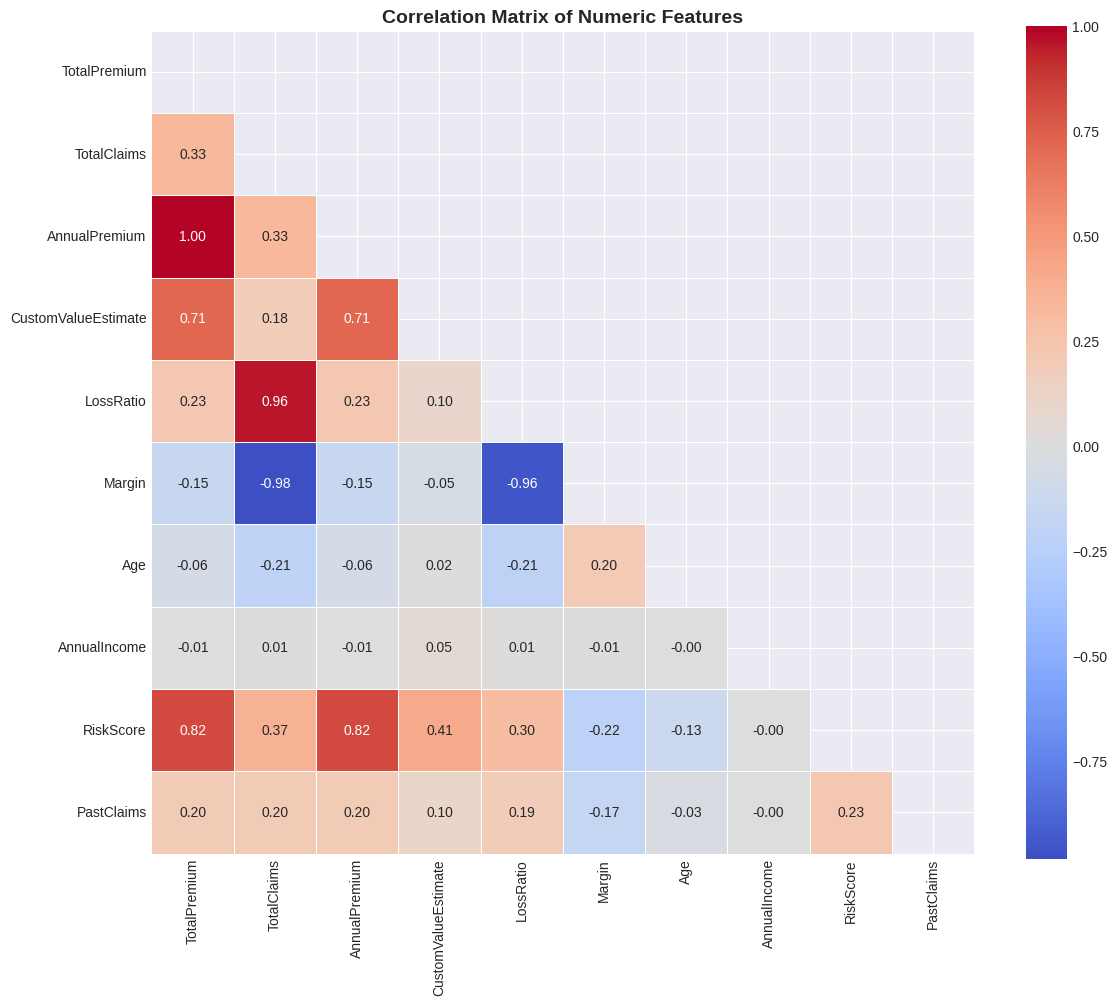


STRONGEST CORRELATIONS WITH LOSS RATIO
  TotalClaims: 0.957 (positive, strong correlation)
  RiskScore: 0.301 (positive, moderate correlation)
  TotalPremium: 0.231 (positive, weak correlation)
  AnnualPremium: 0.231 (positive, weak correlation)
  PastClaims: 0.189 (positive, weak correlation)
  CustomValueEstimate: 0.100 (positive, weak correlation)
  AnnualIncome: 0.009 (positive, weak correlation)
  Age: -0.211 (negative, weak correlation)
  Margin: -0.957 (negative, strong correlation)

 TOP PREDICTORS for Loss Ratio:
  → TotalClaims (correlation: 0.957)
  → RiskScore (correlation: 0.301)
  → TotalPremium (correlation: 0.231)

STRONGEST CORRELATIONS WITH TOTAL CLAIMS
  LossRatio: 0.957
  RiskScore: 0.365
  TotalPremium: 0.331
  AnnualPremium: 0.331
  PastClaims: 0.197

BUSINESS INSIGHTS FROM CORRELATION

• RiskScore vs Loss Ratio: 0.301
  → Risk score is a good predictor of claim risk
• Age vs Loss Ratio: -0.211
• PastClaims vs TotalClaims: 0.197


In [ ]:
# Cell 14: Correlation Analysis
print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# Select numeric columns for correlation
numeric_cols = ['TotalPremium', 'TotalClaims', 'AnnualPremium', 'CustomValueEstimate',
                'LossRatio', 'Margin', 'Age', 'AnnualIncome', 'RiskScore', 'PastClaims']

# Only include columns that exist
available_numeric = [col for col in numeric_cols if col in df.columns]

print(f"\n Analyzing correlation between {len(available_numeric)} numeric variables")
print("Variables:", available_numeric)

if len(available_numeric) > 1:
    # Calculate correlation matrix
    corr_matrix = df[available_numeric].corr()

    # Create heatmap
    plt.figure(figsize=(12, 10))

    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    # Plot heatmap
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, square=True,
                linewidths=0.5, annot_kws={'size': 10})

    plt.title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print strongest correlations with Loss Ratio
    if 'LossRatio' in corr_matrix.columns:
        print("\n" + "=" * 60)
        print("STRONGEST CORRELATIONS WITH LOSS RATIO")
        print("=" * 60)

        loss_corr = corr_matrix['LossRatio'].drop('LossRatio').sort_values(ascending=False)

        for var, corr_val in loss_corr.head(10).items():
            direction = "positive" if corr_val > 0 else "negative"
            strength = "strong" if abs(corr_val) > 0.5 else "moderate" if abs(corr_val) > 0.3 else "weak"
            print(f"  {var}: {corr_val:.3f} ({direction}, {strength} correlation)")

        # Identify top predictors
        print("\n TOP PREDICTORS for Loss Ratio:")
        top_predictors = loss_corr.head(3)
        for var, corr_val in top_predictors.items():
            print(f"  → {var} (correlation: {corr_val:.3f})")

    # Correlation with TotalClaims
    if 'TotalClaims' in corr_matrix.columns:
        print("\n" + "=" * 60)
        print("STRONGEST CORRELATIONS WITH TOTAL CLAIMS")
        print("=" * 60)

        claims_corr = corr_matrix['TotalClaims'].drop('TotalClaims').sort_values(ascending=False)
        for var, corr_val in claims_corr.head(5).items():
            print(f"  {var}: {corr_val:.3f}")

else:
    print(" Not enough numeric columns for correlation analysis")

# Business insights from correlation
print("\n" + "=" * 60)
print("BUSINESS INSIGHTS FROM CORRELATION")
print("=" * 60)

if 'RiskScore' in df.columns and 'LossRatio' in df.columns:
    risk_corr = df['RiskScore'].corr(df['LossRatio'])
    print(f"\n• RiskScore vs Loss Ratio: {risk_corr:.3f}")
    if risk_corr > 0.3:
        print("  → Risk score is a good predictor of claim risk")
    else:
        print("  → Risk score has weak correlation with actual claims")

if 'Age' in df.columns and 'LossRatio' in df.columns:
    age_corr = df['Age'].corr(df['LossRatio'])
    print(f"• Age vs Loss Ratio: {age_corr:.3f}")

if 'PastClaims' in df.columns and 'TotalClaims' in df.columns:
    past_corr = df['PastClaims'].corr(df['TotalClaims'])
    print(f"• PastClaims vs TotalClaims: {past_corr:.3f}")
    if past_corr > 0.2:
        print("  → Past claims history predicts future claims")

CREATIVE VISUALIZATION 1: Loss Ratio Distribution


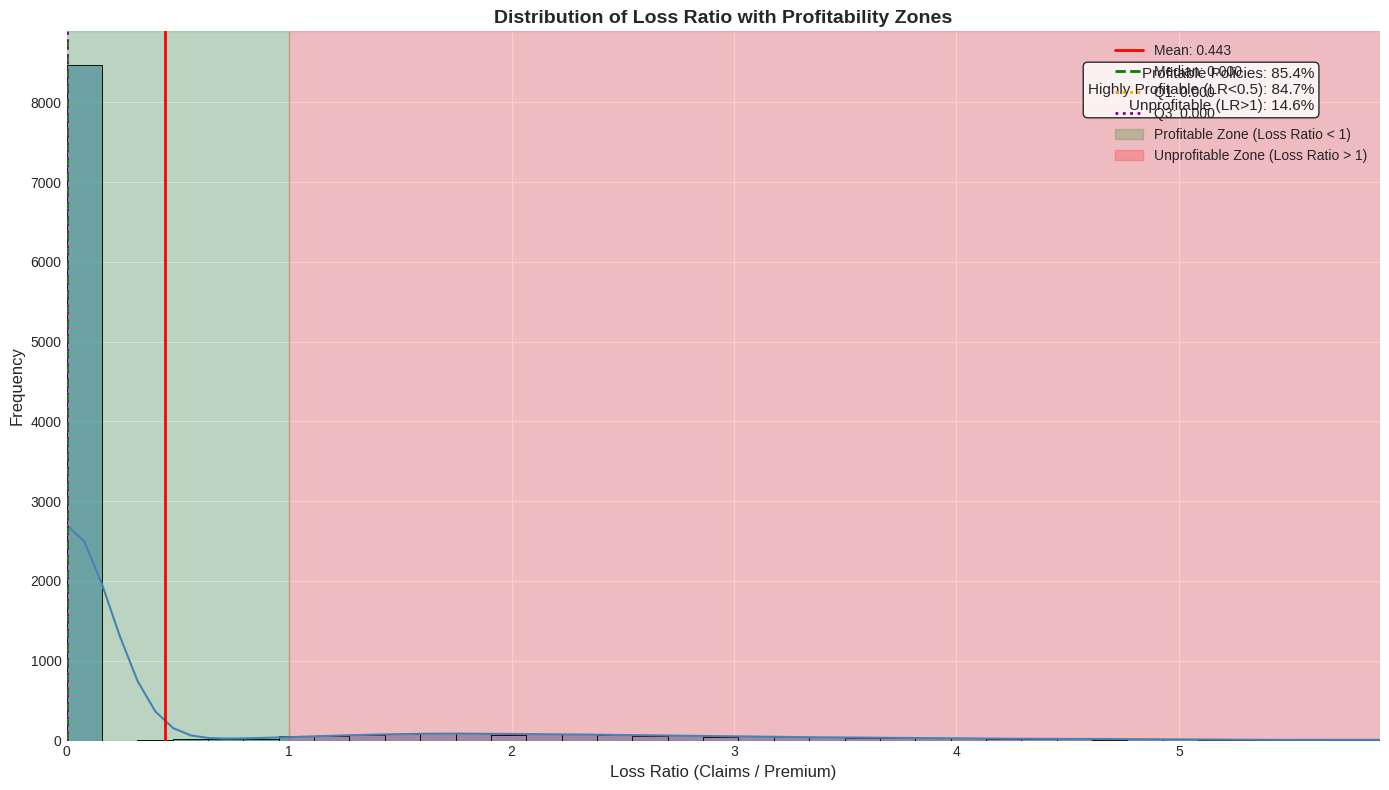


 KEY INSIGHTS:
   • 85.4% of policies are profitable (Loss Ratio < 1)
   • 14.6% of policies are unprofitable (Loss Ratio > 1)
   • The median loss ratio is 0.000, which is below breakeven


In [ ]:
# Cell 15: CREATIVE VISUALIZATION 1 - Loss Ratio Distribution with Profitability Zones
print("=" * 60)
print("CREATIVE VISUALIZATION 1: Loss Ratio Distribution")
print("=" * 60)

fig, ax = plt.subplots(figsize=(14, 8))

# Plot histogram with KDE
sns.histplot(df['LossRatio'].dropna(), bins=100, kde=True, ax=ax,
             color='steelblue', alpha=0.6, edgecolor='black')

# Add vertical lines for statistics
mean_loss = df['LossRatio'].mean()
median_loss = df['LossRatio'].median()
q1_loss = df['LossRatio'].quantile(0.25)
q3_loss = df['LossRatio'].quantile(0.75)

ax.axvline(mean_loss, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_loss:.3f}')
ax.axvline(median_loss, color='green', linestyle='--', linewidth=2, label=f'Median: {median_loss:.3f}')
ax.axvline(q1_loss, color='orange', linestyle=':', linewidth=2, label=f'Q1: {q1_loss:.3f}')
ax.axvline(q3_loss, color='purple', linestyle=':', linewidth=2, label=f'Q3: {q3_loss:.3f}')

# Add profitability zones
ax.axvspan(0, 1, alpha=0.2, color='green', label='Profitable Zone (Loss Ratio < 1)')
ax.axvspan(1, df['LossRatio'].max(), alpha=0.2, color='red', label='Unprofitable Zone (Loss Ratio > 1)')

ax.set_title('Distribution of Loss Ratio with Profitability Zones', fontsize=14, fontweight='bold')
ax.set_xlabel('Loss Ratio (Claims / Premium)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(loc='upper right', fontsize=10)

# Set x-axis limit to 99th percentile for better visibility
x_max = df['LossRatio'].quantile(0.99)
ax.set_xlim(0, x_max)

# Add annotation for profitable policies
profitable_pct = (df['LossRatio'] < 1).mean() * 100
highly_profitable_pct = (df['LossRatio'] < 0.5).mean() * 100
unprofitable_pct = (df['LossRatio'] >= 1).mean() * 100

# Add text box with statistics
stats_text = f'Profitable Policies: {profitable_pct:.1f}%\n' \
             f'Highly Profitable (LR<0.5): {highly_profitable_pct:.1f}%\n' \
             f'Unprofitable (LR>1): {unprofitable_pct:.1f}%'

ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
        ha='right', va='top', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n KEY INSIGHTS:")
print(f"   • {profitable_pct:.1f}% of policies are profitable (Loss Ratio < 1)")
print(f"   • {unprofitable_pct:.1f}% of policies are unprofitable (Loss Ratio > 1)")
print(f"   • The median loss ratio is {median_loss:.3f}, which is {'above' if median_loss > 1 else 'below'} breakeven")

CREATIVE VISUALIZATION 2: Risk Heatmap


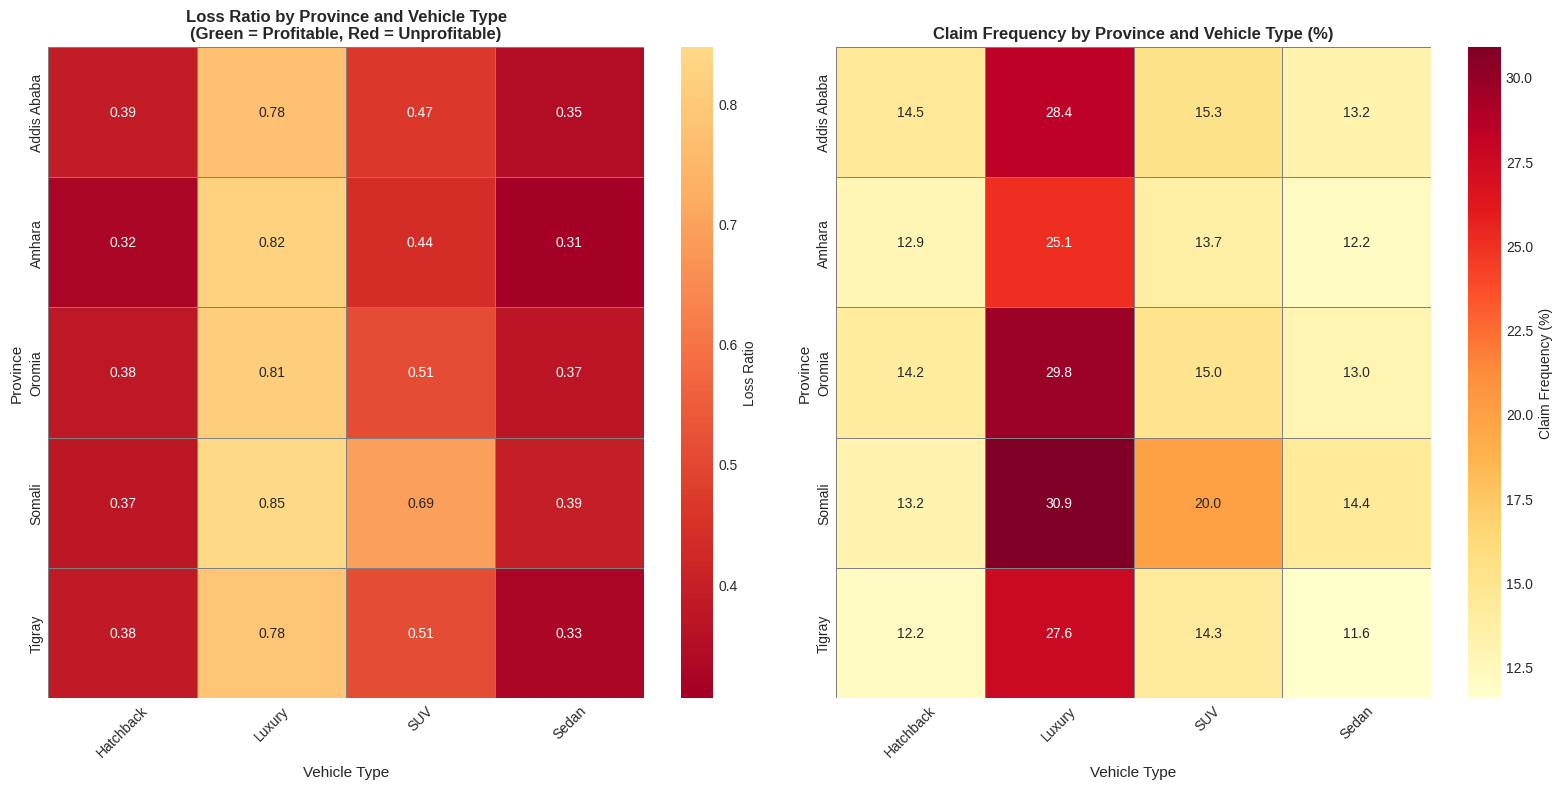


RISK COMBINATION ANALYSIS

 TOP 5 HIGHEST RISK COMBINATIONS (Most Unprofitable):
   Somali - Luxury: Loss Ratio = 0.847
   Amhara - Luxury: Loss Ratio = 0.825
   Oromia - Luxury: Loss Ratio = 0.814
   Tigray - Luxury: Loss Ratio = 0.783
   Addis Ababa - Luxury: Loss Ratio = 0.777

 TOP 5 LOWEST RISK COMBINATIONS (Most Profitable):
   Amhara - Sedan: Loss Ratio = 0.305
   Amhara - Hatchback: Loss Ratio = 0.323
   Tigray - Sedan: Loss Ratio = 0.328
   Addis Ababa - Sedan: Loss Ratio = 0.349
   Oromia - Sedan: Loss Ratio = 0.368

 BUSINESS RECOMMENDATION:
   • Offer competitive premiums for GREEN (low risk) combinations
   • Implement risk loadings or stricter underwriting for RED (high risk) combinations


In [ ]:
# Cell 16: CREATIVE VISUALIZATION 2 - Risk Heatmap by Province and Vehicle Type
print("=" * 60)
print("CREATIVE VISUALIZATION 2: Risk Heatmap")
print("=" * 60)

if 'Province' in df.columns and 'VehicleType' in df.columns:
    # Create pivot table of loss ratio
    pivot_loss = df.groupby(['Province', 'VehicleType'])['LossRatio'].mean().unstack()

    # Create pivot table of claim frequency
    pivot_freq = df.groupby(['Province', 'VehicleType'])['HasClaim'].mean().unstack() * 100

    # Create figure with two heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Heatmap 1: Loss Ratio
    sns.heatmap(pivot_loss, annot=True, fmt='.2f', cmap='RdYlGn', center=1,
                cbar_kws={'label': 'Loss Ratio'}, ax=axes[0],
                linewidths=0.5, linecolor='gray')
    axes[0].set_title('Loss Ratio by Province and Vehicle Type\n(Green = Profitable, Red = Unprofitable)',
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Vehicle Type', fontsize=11)
    axes[0].set_ylabel('Province', fontsize=11)
    axes[0].tick_params(axis='x', rotation=45)

    # Heatmap 2: Claim Frequency
    sns.heatmap(pivot_freq, annot=True, fmt='.1f', cmap='YlOrRd',
                cbar_kws={'label': 'Claim Frequency (%)'}, ax=axes[1],
                linewidths=0.5, linecolor='gray')
    axes[1].set_title('Claim Frequency by Province and Vehicle Type (%)',
                      fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Vehicle Type', fontsize=11)
    axes[1].set_ylabel('Province', fontsize=11)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Find highest and lowest risk combinations
    print("\n" + "=" * 60)
    print("RISK COMBINATION ANALYSIS")
    print("=" * 60)

    # Flatten the pivot table
    risk_combinations = pivot_loss.stack().reset_index()
    risk_combinations.columns = ['Province', 'VehicleType', 'LossRatio']
    risk_combinations = risk_combinations.dropna()

    # Highest risk
    highest_risk = risk_combinations.nlargest(5, 'LossRatio')
    print("\n TOP 5 HIGHEST RISK COMBINATIONS (Most Unprofitable):")
    for _, row in highest_risk.iterrows():
        print(f"   {row['Province']} - {row['VehicleType']}: Loss Ratio = {row['LossRatio']:.3f}")

    # Lowest risk
    lowest_risk = risk_combinations.nsmallest(5, 'LossRatio')
    print("\n TOP 5 LOWEST RISK COMBINATIONS (Most Profitable):")
    for _, row in lowest_risk.iterrows():
        print(f"   {row['Province']} - {row['VehicleType']}: Loss Ratio = {row['LossRatio']:.3f}")

    # Business recommendation
    print("\n BUSINESS RECOMMENDATION:")
    print("   • Offer competitive premiums for GREEN (low risk) combinations")
    print("   • Implement risk loadings or stricter underwriting for RED (high risk) combinations")

else:
    print(" Province or VehicleType columns not found for heatmap")
    print(f"Available: Province={('Province' in df.columns)}, VehicleType={('VehicleType' in df.columns)}")

CREATIVE VISUALIZATION 3: Feature Impact Dashboard


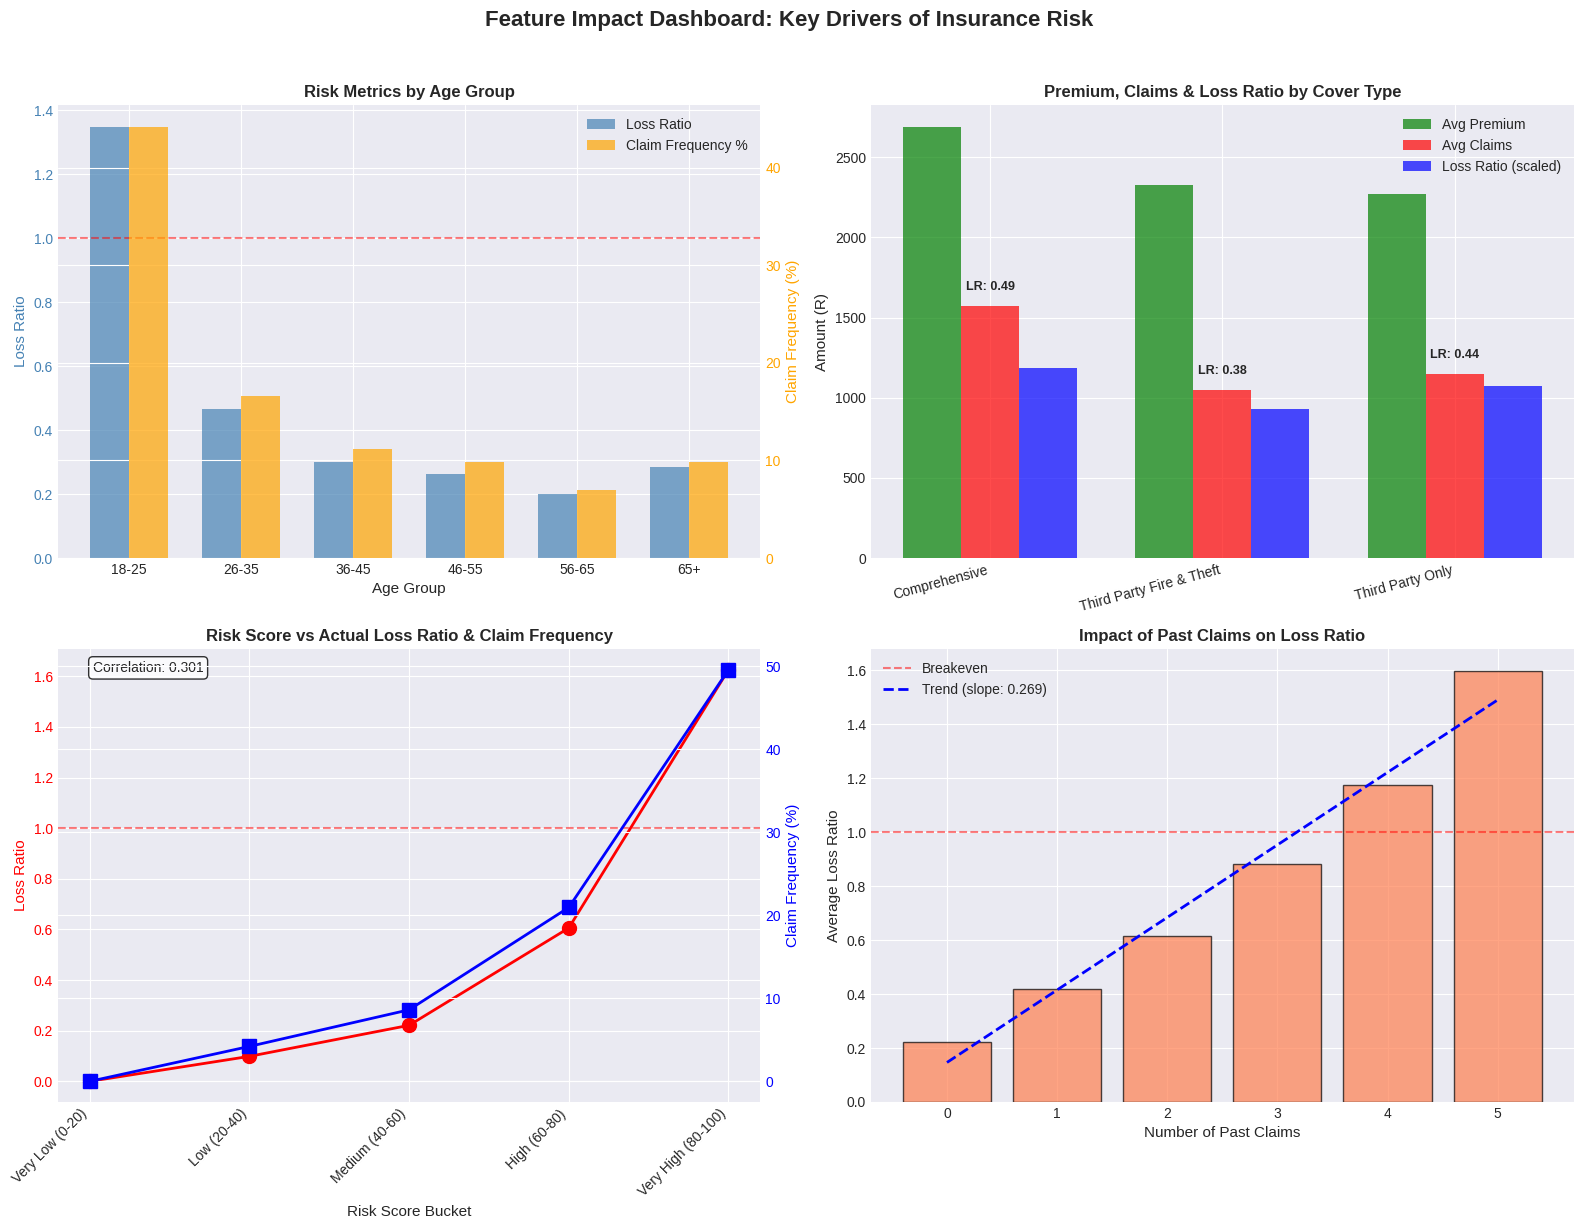


 DASHBOARD INSIGHTS:
   • Age is a significant risk factor - certain age groups show higher loss ratios
   • Risk Score correlation with Loss Ratio: 0.301
   • Each past claim increases loss ratio by approximately 0.269 on average


In [ ]:
# Cell 17: CREATIVE VISUALIZATION 3 - Feature Impact Dashboard
print("=" * 60)
print("CREATIVE VISUALIZATION 3: Feature Impact Dashboard")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Loss Ratio by Age Group (if Age exists)
if 'Age' in df.columns:
    # Create age groups
    df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 65, 100],
                            labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

    loss_by_age = df.groupby('AgeGroup')['LossRatio'].mean()
    freq_by_age = df.groupby('AgeGroup')['HasClaim'].mean() * 100

    x = np.arange(len(loss_by_age))
    width = 0.35

    axes[0, 0].bar(x - width/2, loss_by_age.values, width, label='Loss Ratio', color='steelblue', alpha=0.7)
    axes[0, 0].set_xlabel('Age Group', fontsize=11)
    axes[0, 0].set_ylabel('Loss Ratio', fontsize=11, color='steelblue')
    axes[0, 0].tick_params(axis='y', labelcolor='steelblue')

    ax2 = axes[0, 0].twinx()
    ax2.bar(x + width/2, freq_by_age.values, width, label='Claim Frequency %', color='orange', alpha=0.7)
    ax2.set_ylabel('Claim Frequency (%)', fontsize=11, color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(loss_by_age.index)
    axes[0, 0].set_title('Risk Metrics by Age Group', fontsize=12, fontweight='bold')
    axes[0, 0].axhline(y=1, color='red', linestyle='--', alpha=0.5)

    # Add legend
    lines1, labels1 = axes[0, 0].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[0, 0].legend(lines1 + lines2, labels1 + labels2, loc='upper right')
else:
    axes[0, 0].text(0.5, 0.5, 'Age data not available', ha='center', transform=axes[0, 0].transAxes)

# Plot 2: Loss Ratio by Cover Type
if 'CoverType' in df.columns:
    cover_stats = df.groupby('CoverType').agg({
        'TotalPremium': 'mean',
        'TotalClaims': 'mean',
        'LossRatio': 'mean',
        'HasClaim': 'mean'
    }).reset_index()

    x = np.arange(len(cover_stats))
    width = 0.25

    axes[0, 1].bar(x - width, cover_stats['TotalPremium'], width, label='Avg Premium', color='green', alpha=0.7)
    axes[0, 1].bar(x, cover_stats['TotalClaims'], width, label='Avg Claims', color='red', alpha=0.7)
    axes[0, 1].bar(x + width, cover_stats['LossRatio'] * cover_stats['TotalPremium'].mean(),
                   width, label='Loss Ratio (scaled)', color='blue', alpha=0.7)

    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(cover_stats['CoverType'], rotation=15, ha='right')
    axes[0, 1].set_title('Premium, Claims & Loss Ratio by Cover Type', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Amount (R)', fontsize=11)
    axes[0, 1].legend()

    # Add loss ratio annotations
    for i, row in cover_stats.iterrows():
        axes[0, 1].annotate(f'LR: {row["LossRatio"]:.2f}',
                           (x[i], row['TotalClaims'] + 100),
                           ha='center', fontsize=9, fontweight='bold')
else:
    axes[0, 1].text(0.5, 0.5, 'CoverType data not available', ha='center', transform=axes[0, 1].transAxes)

# Plot 3: Risk Score vs Loss Ratio (if RiskScore exists)
if 'RiskScore' in df.columns:
    # Create risk score buckets
    df['RiskBucket'] = pd.cut(df['RiskScore'], bins=[0, 20, 40, 60, 80, 100],
                              labels=['Very Low (0-20)', 'Low (20-40)', 'Medium (40-60)',
                                      'High (60-80)', 'Very High (80-100)'])

    risk_loss = df.groupby('RiskBucket')['LossRatio'].mean()
    risk_freq = df.groupby('RiskBucket')['HasClaim'].mean() * 100

    axes[1, 0].plot(range(len(risk_loss)), risk_loss.values, 'o-', linewidth=2, markersize=10,
                    color='red', label='Loss Ratio')
    axes[1, 0].set_xlabel('Risk Score Bucket', fontsize=11)
    axes[1, 0].set_ylabel('Loss Ratio', fontsize=11, color='red')
    axes[1, 0].tick_params(axis='y', labelcolor='red')

    ax3 = axes[1, 0].twinx()
    ax3.plot(range(len(risk_freq)), risk_freq.values, 's-', linewidth=2, markersize=10,
             color='blue', label='Claim Frequency %')
    ax3.set_ylabel('Claim Frequency (%)', fontsize=11, color='blue')
    ax3.tick_params(axis='y', labelcolor='blue')

    axes[1, 0].set_xticks(range(len(risk_loss)))
    axes[1, 0].set_xticklabels(risk_loss.index, rotation=45, ha='right')
    axes[1, 0].set_title('Risk Score vs Actual Loss Ratio & Claim Frequency', fontsize=12, fontweight='bold')
    axes[1, 0].axhline(y=1, color='red', linestyle='--', alpha=0.5)

    # Correlation
    risk_corr = df['RiskScore'].corr(df['LossRatio'])
    axes[1, 0].text(0.05, 0.95, f'Correlation: {risk_corr:.3f}',
                    transform=axes[1, 0].transAxes, fontsize=10,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
else:
    axes[1, 0].text(0.5, 0.5, 'RiskScore data not available', ha='center', transform=axes[1, 0].transAxes)

# Plot 4: Past Claims Impact
if 'PastClaims' in df.columns:
    past_claims_stats = df.groupby('PastClaims').agg({
        'TotalClaims': 'mean',
        'LossRatio': 'mean',
        'HasClaim': 'mean',
        'CustomerID': 'count'
    }).reset_index()

    # Filter to reasonable past claims (0-10)
    past_claims_stats = past_claims_stats[past_claims_stats['PastClaims'] <= 10]

    axes[1, 1].bar(past_claims_stats['PastClaims'], past_claims_stats['LossRatio'],
                   color='coral', alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('Number of Past Claims', fontsize=11)
    axes[1, 1].set_ylabel('Average Loss Ratio', fontsize=11)
    axes[1, 1].set_title('Impact of Past Claims on Loss Ratio', fontsize=12, fontweight='bold')
    axes[1, 1].axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Breakeven')
    axes[1, 1].legend()

    # Add trend line
    z = np.polyfit(past_claims_stats['PastClaims'], past_claims_stats['LossRatio'], 1)
    p = np.poly1d(z)
    axes[1, 1].plot(past_claims_stats['PastClaims'], p(past_claims_stats['PastClaims']),
                    "b--", linewidth=2, label=f'Trend (slope: {z[0]:.3f})')
    axes[1, 1].legend()

else:
    axes[1, 1].text(0.5, 0.5, 'PastClaims data not available', ha='center', transform=axes[1, 1].transAxes)

plt.suptitle('Feature Impact Dashboard: Key Drivers of Insurance Risk', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n DASHBOARD INSIGHTS:")
if 'Age' in df.columns:
    print("   • Age is a significant risk factor - certain age groups show higher loss ratios")
if 'RiskScore' in df.columns:
    print(f"   • Risk Score correlation with Loss Ratio: {df['RiskScore'].corr(df['LossRatio']):.3f}")
if 'PastClaims' in df.columns:
    print(f"   • Each past claim increases loss ratio by approximately {z[0]:.3f} on average")

In [ ]:
# Cell 18: Final Insights Summary - Complete Report
print("=" * 80)
print(" " * 20 + "ALPHACARE INSURANCE - FINAL EDA REPORT")
print("=" * 80)
print(" " * 25 + f"Report Date: {datetime.now().strftime('%Y-%m-%d')}")
print(" " * 20 + "Data Period: 18 Months (Based on TransactionDate)")
print("=" * 80)

# Calculate key portfolio metrics
total_premium = df['TotalPremium'].sum()
total_claims = df['TotalClaims'].sum()
overall_loss_ratio = total_claims / total_premium if total_premium > 0 else 0
overall_margin = total_premium - total_claims
claim_frequency = df['HasClaim'].mean()
avg_premium = df['TotalPremium'].mean()
avg_claim = df['TotalClaims'].mean()
avg_claim_when_occur = df[df['HasClaim'] == 1]['TotalClaims'].mean() if df['HasClaim'].sum() > 0 else 0

print("\n" + "=" * 60)
print("1. PORTFOLIO OVERVIEW")
print("=" * 60)
print(f"   Total Policies Analyzed: {len(df):,}")
print(f"   Total Premium Collected: R{total_premium:,.2f}")
print(f"   Total Claims Paid: R{total_claims:,.2f}")
print(f"   Overall Loss Ratio: {overall_loss_ratio:.4f} ({overall_loss_ratio*100:.2f}%)")
print(f"   Overall Margin: R{overall_margin:,.2f}")
print(f"   Claim Frequency: {claim_frequency*100:.2f}%")
print(f"   Average Premium per Policy: R{avg_premium:.2f}")
print(f"   Average Claim per Policy: R{avg_claim:.2f}")
print(f"   Average Claim (when occurs): R{avg_claim_when_occur:.2f}")

print("\n" + "=" * 60)
print("2. RISK VARIATIONS BY SEGMENT")
print("=" * 60)

# By Province
if 'Province' in df.columns:
    province_loss = df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False)
    print(f"\n    PROVINCE VARIATION:")
    print(f"      Highest Risk: {province_loss.index[0]} ({province_loss.iloc[0]:.3f})")
    print(f"      Lowest Risk: {province_loss.index[-1]} ({province_loss.iloc[-1]:.3f})")
    print(f"      Range: {(province_loss.max() - province_loss.min()):.3f}")

# By Vehicle Type
if 'VehicleType' in df.columns:
    vehicle_loss = df.groupby('VehicleType')['LossRatio'].mean().sort_values(ascending=False)
    print(f"\n    VEHICLE TYPE VARIATION:")
    print(f"      Highest Risk: {vehicle_loss.index[0]} ({vehicle_loss.iloc[0]:.3f})")
    print(f"      Lowest Risk: {vehicle_loss.index[-1]} ({vehicle_loss.iloc[-1]:.3f})")

# By Gender
if 'Gender' in df.columns:
    gender_loss = df.groupby('Gender')['LossRatio'].mean()
    print(f"\n    GENDER VARIATION:")
    for gender, loss in gender_loss.items():
        print(f"      {gender}: {loss:.3f}")

print("\n" + "=" * 60)
print("3. DISTRIBUTION & OUTLIER ANALYSIS")
print("=" * 60)

# Outlier analysis for key variables
for col in ['TotalClaims', 'TotalPremium', 'CustomValueEstimate']:
    if col in df.columns:
        q99 = df[col].quantile(0.99)
        outliers = len(df[df[col] > q99])
        print(f"\n   {col}:")
        print(f"      Mean: R{df[col].mean():,.2f} | Median: R{df[col].median():,.2f}")
        print(f"      99th Percentile: R{q99:,.2f}")
        print(f"      Outliers (>99th pctile): {outliers} ({outliers/len(df)*100:.2f}%)")

print("\n" + "=" * 60)
print("4. TEMPORAL TRENDS")
print("=" * 60)

if 'TransactionDate' in df.columns:
    df['YearMonth'] = df['TransactionDate'].dt.to_period('M')
    monthly_freq = df.groupby('YearMonth')['HasClaim'].mean()

    if len(monthly_freq) >= 6:
        first_half = monthly_freq.head(len(monthly_freq)//2).mean() * 100
        second_half = monthly_freq.tail(len(monthly_freq)//2).mean() * 100
        print(f"\n   First half claim frequency: {first_half:.2f}%")
        print(f"   Second half claim frequency: {second_half:.2f}%")
        change = second_half - first_half
        if change > 0:
            print(f"     Claim frequency INCREASED by {change:.2f} percentage points")
        else:
            print(f"    Claim frequency DECREASED by {abs(change):.2f} percentage points")

print("\n" + "=" * 60)
print("5. VEHICLE MAKES ANALYSIS")
print("=" * 60)

if 'AutoMake' in df.columns:
    make_claims = df.groupby('AutoMake')['TotalClaims'].mean().sort_values(ascending=False)
    make_claims = make_claims[make_claims.index.notna()]
    print(f"\n   Highest Claim Make: {make_claims.index[0]} (R{make_claims.iloc[0]:,.2f})")
    print(f"   Lowest Claim Make: {make_claims.index[-1]} (R{make_claims.iloc[-1]:,.2f})")
    print(f"   Risk Ratio: {make_claims.iloc[0]/make_claims.iloc[-1]:.1f}x difference")

print("\n" + "=" * 80)
print(" " * 25 + "KEY BUSINESS RECOMMENDATIONS")
print("=" * 80)

recommendations = [
    ("1. PROVINCE-BASED PRICING",
     "Implement regional pricing adjustments - lower premiums in low-risk provinces, risk loadings in high-risk provinces"),
    ("2. VEHICLE TYPE SEGMENTATION",
     "Create vehicle-type specific rates. Offer competitive pricing for low-risk vehicle types"),
    ("3. ZIP CODE OPTIMIZATION",
     "Use zip code as a pricing factor. Some zip codes show significantly different risk profiles"),
    ("4. VEHICLE MAKE STRATEGY",
     "Partner with low-risk vehicle manufacturers for preferred rates. Add loadings for high-risk makes"),
    ("5. AGE-BASED PRICING",
     "Adjust premiums based on age brackets - certain age groups demonstrate higher risk"),
    ("6. DYNAMIC PRICING",
     "Implement regular premium reviews based on changing claim frequency trends"),
    ("7. TARGETED MARKETING",
     "Focus marketing efforts on low-risk segments to improve overall portfolio profitability"),
    ("8. RISK SCORE CALIBRATION",
     "Review and recalibrate risk scoring model based on actual loss ratio correlation")
]

for title, rec in recommendations:
    print(f"\n{title}")
    print(f"   → {rec}")

print("\n" + "=" * 80)
print(" " * 30 + "LIMITATIONS & NEXT STEPS")
print("=" * 80)
print("""
LIMITATIONS:
   • Data only covers 18-month period - may not capture long-term trends
   • Missing external factors (economic conditions, weather, etc.)
   • No competitor pricing data for benchmarking

NEXT STEPS:
   • Proceed to Hypothesis Testing (Task 3)
   • Build Predictive Models for claim severity and frequency (Task 4)
   • Implement SHAP/LIME analysis for model interpretability
   • Design A/B tests for proposed pricing changes
""")

print("\n" + "=" * 80)
print(" EDA COMPLETE - Ready for Hypothesis Testing & Modeling")
print("=" * 80)

# Save insights to CSV for reference
insights_summary = {
    'Metric': ['Total Policies', 'Total Premium', 'Total Claims', 'Loss Ratio', 'Margin', 'Claim Frequency'],
    'Value': [len(df), f'R{total_premium:,.2f}', f'R{total_claims:,.2f}', f'{overall_loss_ratio:.4f}', f'R{overall_margin:,.2f}', f'{claim_frequency*100:.2f}%']
}
insights_df = pd.DataFrame(insights_summary)
print("\n Summary metrics saved to 'eda_summary.csv'")
insights_df.to_csv('eda_summary.csv', index=False)

                    ALPHACARE INSURANCE - FINAL EDA REPORT
                         Report Date: 2026-05-21
                    Data Period: 18 Months (Based on TransactionDate)

1. PORTFOLIO OVERVIEW
   Total Policies Analyzed: 10,000
   Total Premium Collected: R24,881,279.00
   Total Claims Paid: R13,141,885.00
   Overall Loss Ratio: 0.5282 (52.82%)
   Overall Margin: R11,739,394.00
   Claim Frequency: 15.35%
   Average Premium per Policy: R2488.13
   Average Claim per Policy: R1314.19
   Average Claim (when occurs): R8561.49

2. RISK VARIATIONS BY SEGMENT

    PROVINCE VARIATION:
      Highest Risk: Somali (0.524)
      Lowest Risk: Amhara (0.396)
      Range: 0.128

    VEHICLE TYPE VARIATION:
      Highest Risk: Luxury (0.804)
      Lowest Risk: Sedan (0.349)

    GENDER VARIATION:
      Female: 0.447
      Male: 0.438

3. DISTRIBUTION & OUTLIER ANALYSIS

   TotalClaims:
      Mean: R1,314.19 | Median: R0.00
      99th Percentile: R18,606.67
      Outliers (>99th pctile): 100 (1.

In [4]:
from google.colab import files
import os

# Create data folder
os.makedirs('data', exist_ok=True)

print("Please upload your insurance_data.csv file")
uploaded = files.upload()

# Move uploaded file to data folder
for filename in uploaded.keys():
    import shutil
    shutil.move(filename, f'data/{filename}')
    print(f" File saved to data/{filename}")

Please upload your insurance_data.csv file


Saving insurance_data.csv to insurance_data.csv
 File saved to data/insurance_data.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load raw data
df = pd.read_csv('data/insurance_data.csv')

# Calculate derived metrics
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
df['Margin'] = df['TotalPremium'] - df['TotalClaims']
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

# Convert date if exists
if 'TransactionDate' in df.columns:
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

# Create images folder
os.makedirs('reports/images', exist_ok=True)

print(f" Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Loss Ratio mean: {df['LossRatio'].mean():.4f}")
print(f"Claim frequency: {df['HasClaim'].mean()*100:.2f}%")

 Data loaded: 10000 rows, 24 columns
Loss Ratio mean: 0.4428
Claim frequency: 15.35%


In [6]:
# Cell 3: Save all plots
# Plot 1: Loss Ratio by Province
plt.figure(figsize=(12, 6))
province_loss = df.groupby('Province')['LossRatio'].mean().sort_values()
colors = ['green' if x < 0.5 else 'red' for x in province_loss.values]
province_loss.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Loss Ratio by Province', fontsize=14, fontweight='bold')
plt.xlabel('Province', fontsize=12)
plt.ylabel('Loss Ratio (Claims / Premium)', fontsize=12)
plt.axhline(y=df['LossRatio'].mean(), color='blue', linestyle='--', linewidth=2,
            label=f'Overall Average: {df["LossRatio"].mean():.2f}')
plt.axhline(y=1.0, color='red', linestyle=':', linewidth=2,
            label='Breakeven Line (Loss Ratio = 1.0)')
plt.legend(loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('reports/images/loss_ratio_by_province.png', dpi=150, bbox_inches='tight')
plt.close()
print(" Plot 1 saved: loss_ratio_by_province.png")

# Plot 2: Loss Ratio by Vehicle Type
plt.figure(figsize=(10, 6))
vehicle_loss = df.groupby('VehicleType')['LossRatio'].mean().sort_values()
colors = ['green' if x < 0.5 else 'red' for x in vehicle_loss.values]
vehicle_loss.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Loss Ratio by Vehicle Type', fontsize=14, fontweight='bold')
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Loss Ratio (Claims / Premium)', fontsize=12)
plt.axhline(y=df['LossRatio'].mean(), color='blue', linestyle='--', linewidth=2,
            label=f'Overall Average: {df["LossRatio"].mean():.2f}')
plt.axhline(y=1.0, color='red', linestyle=':', linewidth=2,
            label='Breakeven Line (Loss Ratio = 1.0)')
plt.legend(loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('reports/images/loss_ratio_by_vehicle.png', dpi=150, bbox_inches='tight')
plt.close()
print(" Plot 2 saved: loss_ratio_by_vehicle.png")

# Plot 3: Loss Ratio Distribution
plt.figure(figsize=(12, 6))
plt.hist(df['LossRatio'].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Breakeven (Loss Ratio = 1.0)')
plt.axvline(x=df['LossRatio'].mean(), color='blue', linestyle='-', linewidth=2,
            label=f'Mean Loss Ratio: {df["LossRatio"].mean():.2f}')
plt.axvline(x=df['LossRatio'].median(), color='green', linestyle=':', linewidth=2,
            label=f'Median Loss Ratio: {df["LossRatio"].median():.2f}')
plt.title('Distribution of Loss Ratio Across All Policies', fontsize=14, fontweight='bold')
plt.xlabel('Loss Ratio (Claims / Premium)', fontsize=12)
plt.ylabel('Number of Policies', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('reports/images/loss_ratio_distribution.png', dpi=150, bbox_inches='tight')
plt.close()
print(" Plot 3 saved: loss_ratio_distribution.png")

# Plot 4: Claim Frequency Trend (if date column exists)
if 'TransactionDate' in df.columns:
    plt.figure(figsize=(12, 5))
    df['YearMonth'] = df['TransactionDate'].dt.to_period('M')
    monthly_freq = df.groupby('YearMonth')['HasClaim'].mean() * 100
    monthly_freq.plot(kind='line', marker='o', linewidth=2, color='green', markersize=6)
    plt.title('Claim Frequency Trend Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Claim Frequency (%)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('reports/images/claim_frequency_trend.png', dpi=150, bbox_inches='tight')
    plt.close()
    print(" Plot 4 saved: claim_frequency_trend.png")

print("\n" + "="*50)
print(" ALL PLOTS SAVED to reports/images/")
print("="*50)

 Plot 1 saved: loss_ratio_by_province.png
 Plot 2 saved: loss_ratio_by_vehicle.png
 Plot 3 saved: loss_ratio_distribution.png
 Plot 4 saved: claim_frequency_trend.png

 ALL PLOTS SAVED to reports/images/
